In [1]:
import os
import gzip
import json
import pandas as pd
from typing import Optional, List, Callable, Dict, Any, Iterable, Union

def _open_text(path: str):
    """Open normal text file or .gz file as a text stream."""
    return gzip.open(path, "rt", encoding="utf-8") if path.endswith(".gz") else open(path, "r", encoding="utf-8")

def iter_jsonl_chunks(
    path: str,
    chunksize: int = 100_000,
    columns: Optional[List[str]] = None,
    row_filter: Optional[Callable[[Dict[str, Any]], bool]] = None,
    verbose: bool = True,
) -> Iterable[pd.DataFrame]:
    """
    Stream a JSON Lines file and yield DataFrame chunks.
    - columns: keep only required keys (saves RAM)
    - row_filter: filter rows while reading (saves RAM + time)
    """
    if not os.path.exists(path):
        raise FileNotFoundError(f"File not found: {path}")

    buf = []
    total = 0

    with _open_text(path) as f:
        for i, line in enumerate(f, start=1):
            line = line.strip()
            if not line:
                continue

            obj = json.loads(line)

            if row_filter and not row_filter(obj):
                continue

            if columns is not None:
                obj = {k: obj.get(k, None) for k in columns}

            buf.append(obj)

            if len(buf) >= chunksize:
                df = pd.DataFrame(buf)
                total += len(df)
                if verbose:
                    print(f"✅ yielded {len(df):,} rows | total read {total:,}")
                yield df
                buf = []

    if buf:
        df = pd.DataFrame(buf)
        total += len(df)
        if verbose:
            print(f"✅ yielded FINAL {len(df):,} rows | total read {total:,}")
        yield df


In [2]:
def load_and_peek(
    path: str,
    chunksize: int = 100_000,
    columns: Optional[List[str]] = None,
    row_filter: Optional[Callable[[Dict[str, Any]], bool]] = None,
    peek_rows: int = 5_000,          # preview rows without loading everything
    full_load: bool = False,         # set True only if you have enough RAM
):
    chunk_iter = iter_jsonl_chunks(
        path=path,
        chunksize=chunksize,
        columns=columns,
        row_filter=row_filter,
        verbose=True
    )

    # Preview safely
    preview_parts = []
    remaining = peek_rows

    for chunk in chunk_iter:
        take = min(remaining, len(chunk))
        preview_parts.append(chunk.head(take))
        remaining -= take
        if remaining <= 0:
            break



    # Full load (RAM heavy)
    print("\n⚠️ Full loading entire file into memory...")
    full_df = pd.concat(
        iter_jsonl_chunks(path, chunksize=chunksize, columns=columns, row_filter=row_filter, verbose=True),
        ignore_index=True
    )

    print("\n===== FULL DATA LOADED =====")
    print("Shape:", full_df.shape)
    display(full_df.head(10))
    return full_df


In [3]:
business_preview = load_and_peek(
    "./yelp_dataset/filtered_food_data.json",
    chunksize=50_000,
    # columns=business_cols,
    peek_rows=5000,
    full_load=True
)


✅ yielded 50,000 rows | total read 50,000

⚠️ Full loading entire file into memory...
✅ yielded 50,000 rows | total read 50,000
✅ yielded FINAL 16,770 rows | total read 66,770

===== FULL DATA LOADED =====
Shape: (66770, 9)


,business_id,city,state,postal_code,latitude,longitude,categories,category_list,filtered_categories
0,MTSW4McQd7CbVtyjqoe9mw,Philadelphia,PA,19107,39.955505,-75.155564,"Restaurants, Food, Bubble Tea, Coffee & Tea, B...","[Restaurants, Food, Bubble Tea, Coffee & Tea, ...","[Restaurants, Food, Bubble Tea, Coffee & Tea, ..."
1,mWMc6_wTdE0EUBKIGXDVfA,Green Lane,PA,18054,40.338183,-75.471659,"Brewpubs, Breweries, Food","[Brewpubs, Breweries, Food]","[Brewpubs, Breweries, Food]"
2,CF33F8-E6oudUQ46HnavjQ,Ashland City,TN,37015,36.269593,-87.058943,"Burgers, Fast Food, Sandwiches, Food, Ice Crea...","[Burgers, Fast Food, Sandwiches, Food, Ice Cre...","[Burgers, Fast Food, Sandwiches, Food, Ice Cre..."
3,k0hlBqXX-Bt0vf1op7Jr1w,Affton,MO,63123,38.565165,-90.321087,"Pubs, Restaurants, Italian, Bars, American (Tr...","[Pubs, Restaurants, Italian, Bars, American (T...","[Pubs, Restaurants, Italian, Bars, American (T..."
4,bBDDEgkFA1Otx9Lfe7BZUQ,Nashville,TN,37207,36.208102,-86.768170,"Ice Cream & Frozen Yogurt, Fast Food, Burgers,...","[Ice Cream & Frozen Yogurt, Fast Food, Burgers...","[Ice Cream & Frozen Yogurt, Fast Food, Burgers..."
5,eEOYSgkmpB90uNA7lDOMRA,Tampa Bay,FL,33602,27.955269,-82.456320,"Vietnamese, Food, Restaurants, Food Trucks","[Vietnamese, Food, Restaurants, Food Trucks]","[Vietnamese, Food, Restaurants]"
6,il_Ro8jwPlHresjw9EGmBg,Indianapolis,IN,46227,39.637133,-86.127217,"American (Traditional), Restaurants, Diners, B...","[American (Traditional), Restaurants, Diners, ...","[American (Traditional), Restaurants, Breakfas..."
7,0bPLkL0QhhPO5kt1_EXmNQ,Largo,FL,33771,27.916116,-82.760461,"Food, Delis, Italian, Bakeries, Restaurants","[Food, Delis, Italian, Bakeries, Restaurants]","[Food, Italian, Bakeries, Restaurants]"
8,MUTTqe8uqyMdBl186RmNeA,Philadelphia,PA,19106,39.953949,-75.143226,"Sushi Bars, Restaurants, Japanese","[Sushi Bars, Restaurants, Japanese]","[Sushi Bars, Restaurants]"
9,ROeacJQwBeh05Rqg7F6TCg,Philadelphia,PA,19147,39.943223,-75.162568,"Korean, Restaurants","[Korean, Restaurants]","[Korean, Restaurants]"


In [4]:
# Count businesses per state to check the business distribution across states
state_counts = (
    business_preview
    .groupby("state")
    .size()
    .reset_index(name="business_count")
    .sort_values("business_count", ascending=False)
)

state_counts.head(10)


,state,business_count
16,PA,15826
5,FL,11261
17,TN,5460
11,MO,5283
9,IN,5270
10,LA,4845
14,NJ,4173
1,AZ,3452
0,AB,3056
15,NV,2396


In [5]:
# Top 10 states by number of businesses
top_10_states = (
    state_counts
    .sort_values("business_count", ascending=False)
    .head(10)["state"]
    .tolist()
)

top_10_states


['PA', 'FL', 'TN', 'MO', 'IN', 'LA', 'NJ', 'AZ', 'AB', 'NV']

In [6]:
business_top_states = business_preview[
    business_preview["state"].isin(top_10_states)
]

business_top_states.shape
business_top_states.head()


,business_id,city,state,postal_code,latitude,longitude,categories,category_list,filtered_categories
0,MTSW4McQd7CbVtyjqoe9mw,Philadelphia,PA,19107,39.955505,-75.155564,"Restaurants, Food, Bubble Tea, Coffee & Tea, B...","[Restaurants, Food, Bubble Tea, Coffee & Tea, ...","[Restaurants, Food, Bubble Tea, Coffee & Tea, ..."
1,mWMc6_wTdE0EUBKIGXDVfA,Green Lane,PA,18054,40.338183,-75.471659,"Brewpubs, Breweries, Food","[Brewpubs, Breweries, Food]","[Brewpubs, Breweries, Food]"
2,CF33F8-E6oudUQ46HnavjQ,Ashland City,TN,37015,36.269593,-87.058943,"Burgers, Fast Food, Sandwiches, Food, Ice Crea...","[Burgers, Fast Food, Sandwiches, Food, Ice Cre...","[Burgers, Fast Food, Sandwiches, Food, Ice Cre..."
3,k0hlBqXX-Bt0vf1op7Jr1w,Affton,MO,63123,38.565165,-90.321087,"Pubs, Restaurants, Italian, Bars, American (Tr...","[Pubs, Restaurants, Italian, Bars, American (T...","[Pubs, Restaurants, Italian, Bars, American (T..."
4,bBDDEgkFA1Otx9Lfe7BZUQ,Nashville,TN,37207,36.208102,-86.768170,"Ice Cream & Frozen Yogurt, Fast Food, Burgers,...","[Ice Cream & Frozen Yogurt, Fast Food, Burgers...","[Ice Cream & Frozen Yogurt, Fast Food, Burgers..."


### Checkin Preview 

In [7]:
checkin_preview = load_and_peek(
    "./yelp_dataset/yelp_academic_dataset_checkin.json",
    chunksize=50_000,
    # columns=business_cols,
    peek_rows=5000,
    full_load=True
)

✅ yielded 50,000 rows | total read 50,000

⚠️ Full loading entire file into memory...
✅ yielded 50,000 rows | total read 50,000
✅ yielded 50,000 rows | total read 100,000
✅ yielded FINAL 31,930 rows | total read 131,930

===== FULL DATA LOADED =====
Shape: (131930, 2)


,business_id,date
0,---kPU91CF4Lq2-WlRu9Lw,"2020-03-13 21:10:56, 2020-06-02 22:18:06, 2020..."
1,--0iUa4sNDFiZFrAdIWhZQ,"2010-09-13 21:43:09, 2011-05-04 23:08:15, 2011..."
2,--30_8IhuyMHbSOcNWd6DQ,"2013-06-14 23:29:17, 2014-08-13 23:20:22"
3,--7PUidqRWpRSpXebiyxTg,"2011-02-15 17:12:00, 2011-07-28 02:46:10, 2012..."
4,--7jw19RH9JKXgFohspgQw,"2014-04-21 20:42:11, 2014-04-28 21:04:46, 2014..."
5,--8IbOsAAxjKRoYsBFL-PA,"2015-06-06 01:03:19, 2015-07-29 16:50:58, 2015..."
6,--9osgUCSDUWUkoTLdvYhQ,"2015-06-13 02:00:57, 2015-07-04 00:44:09, 2015..."
7,--ARBQr1WMsTWiwOKOj-FQ,"2014-12-12 00:44:23, 2015-01-09 00:19:52, 2015..."
8,--FWWsIwxRwuw9vIMImcQg,"2010-09-11 16:28:39, 2010-12-22 21:14:19, 2011..."
9,--FcbSxK1AoEtEAxOgBaCw,"2017-08-18 19:43:50, 2017-10-07 22:38:38, 2017..."


In [8]:
# same for review dataset if needed
review_preview = load_and_peek(
    "./yelp_dataset/yelp_academic_dataset_review.json", 
    chunksize=50_000,
    peek_rows=5000,
    full_load=True
)

✅ yielded 50,000 rows | total read 50,000

⚠️ Full loading entire file into memory...
✅ yielded 50,000 rows | total read 50,000
✅ yielded 50,000 rows | total read 100,000
✅ yielded 50,000 rows | total read 150,000
✅ yielded 50,000 rows | total read 200,000
✅ yielded 50,000 rows | total read 250,000
✅ yielded 50,000 rows | total read 300,000
✅ yielded 50,000 rows | total read 350,000
✅ yielded 50,000 rows | total read 400,000
✅ yielded 50,000 rows | total read 450,000
✅ yielded 50,000 rows | total read 500,000
✅ yielded 50,000 rows | total read 550,000
✅ yielded 50,000 rows | total read 600,000
✅ yielded 50,000 rows | total read 650,000
✅ yielded 50,000 rows | total read 700,000
✅ yielded 50,000 rows | total read 750,000
✅ yielded 50,000 rows | total read 800,000
✅ yielded 50,000 rows | total read 850,000
✅ yielded 50,000 rows | total read 900,000
✅ yielded 50,000 rows | total read 950,000
✅ yielded 50,000 rows | total read 1,000,000
✅ yielded 50,000 rows | total read 1,050,000
✅ yielde

,review_id,user_id,business_id,stars,useful,funny,cool,text,date
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3.0,0,0,0,"If you decide to eat here, just be aware it is...",2018-07-07 22:09:11
1,BiTunyQ73aT9WBnpR9DZGw,OyoGAe7OKpv6SyGZT5g77Q,7ATYjTIgM3jUlt4UM3IypQ,5.0,1,0,1,I've taken a lot of spin classes over the year...,2012-01-03 15:28:18
2,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3.0,0,0,0,Family diner. Had the buffet. Eclectic assortm...,2014-02-05 20:30:30
3,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5.0,1,0,1,"Wow! Yummy, different, delicious. Our favo...",2015-01-04 00:01:03
4,Sx8TMOWLNuJBWer-0pcmoA,bcjbaE6dDog4jkNY91ncLQ,e4Vwtrqf-wpJfwesgvdgxQ,4.0,1,0,1,Cute interior and owner (?) gave us tour of up...,2017-01-14 20:54:15
5,JrIxlS1TzJ-iCu79ul40cQ,eUta8W_HdHMXPzLBBZhL1A,04UD14gamNjLY0IDYVhHJg,1.0,1,2,1,I am a long term frequent customer of this est...,2015-09-23 23:10:31
6,6AxgBCNX_PNTOxmbRSwcKQ,r3zeYsv1XFBRA4dJpL78cw,gmjsEdUsKpj9Xxu6pdjH0g,5.0,0,2,0,Loved this tour! I grabbed a groupon and the p...,2015-01-03 23:21:18
7,_ZeMknuYdlQcUqng_Im3yg,yfFzsLmaWF2d4Sr0UNbBgg,LHSTtnW3YHCeUkRDGyJOyw,5.0,2,0,0,Amazingly amazing wings and homemade bleu chee...,2015-08-07 02:29:16
8,ZKvDG2sBvHVdF5oBNUOpAQ,wSTuiTk-sKNdcFyprzZAjg,B5XSoSG3SfvQGtKEGQ1tSQ,3.0,1,1,0,This easter instead of going to Lopez Lake we ...,2016-03-30 22:46:33
9,pUycOfUwM8vqX7KjRRhUEA,59MxRhNVhU9MYndMkz0wtw,gebiRewfieSdtt17PTW6Zg,3.0,0,0,0,Had a party of 6 here for hibachi. Our waitres...,2016-07-25 07:31:06


In [9]:
DIETARY_GROUPS = {
    # Sugar / dessert seeking
    "High_Sugar_Dessert": {
        "Ice Cream", "Frozen Yogurt", "Ice Cream & Frozen Yogurt",
        "Desserts", "Cupcakes", "Bakery", "Bakeries"
    },

    # Energy-dense / fast food seeking
    "Energy_Dense_Food": {
        "Fast Food", "Burger", "Burgers", "Pizza", "Sandwich", "Sandwiches",
        "BBQ", "Buffet", "Food Trucks", "Delis"
    },

    # Hot comfort food (weather-sensitive)
    "Hot_Comfort_Food": {
        "Soup", "Noodles", "Ramen", "Hot Pot", "Curry"
    },

    # Caffeinated / beverage seeking (often sugar too, but keep separate for interpretability)
    "Caffeinated_Beverage": {
        "Coffee", "Tea", "Coffee & Tea", "Cafes", "Cafe"
    },

    # Sweet / non-caffeinated beverages
    "Sweet_Beverage": {
        "Bubble Tea", "Juice", "Smoothie", "Juice Bars", "Juice Bars & Smoothies"
    },

    # Alcohol-related consumption proxy
    "Alcohol_Consumption": {
        "Bar", "Bars", "Pub", "Pubs", "Brewery", "Brewpub", "Wine", "Wine Bars"
    },

    # Health-oriented choices
    "Healthy_Light_Meal": {
        "Vegan", "Vegetarian", "Health Food", "Organic", "Salad"
    },

    # Meal timing / breakfast pattern
    "Breakfast_Brunch": {
        "Breakfast", "Brunch", "Breakfast & Brunch"
    },
    
    "Full_Service_Meal":{

    # Asian cuisines
    "Chinese", "Chinese Food", "Thai", "Japanese", "Korean",
    "Vietnamese", "Indian", "Malaysian", "Asian Fusion",

    # European / Western cuisines
    "Italian", "French", "Greek", "Mediterranean",
    "American", "American (Traditional)", "American (New)",
    "Canadian",

    # Other cuisines
    "Mexican", "Latin American", "Middle Eastern",
    "Turkish", "Caribbean", "African",

    # Protein-focused sit-down meals
    "Seafood", "Steakhouse", "Steakhouses"
    }

}


In [10]:
GENERAL_TERMS = {"Food", "Restaurant", "Restaurants", "Food Court", "Bistro", "Bistros"}

In [11]:
DIETARY_PRIORITY = [
    "Alcohol_Consumption",
    "High_Sugar_Dessert",
    "Sweet_Beverage",
    "Caffeinated_Beverage",
    "Energy_Dense_Food",
    "Hot_Comfort_Food",
    "Healthy_Light_Meal",
    "Breakfast_Brunch",
    "Full_Service_Meal",
]


In [12]:
def map_to_dietary_behavior(filtered_categories):
    """
    filtered_categories: list of strings (your existing list column)
    returns: one dietary_behavior_type label (string) or 'Other'
    """
    if not isinstance(filtered_categories, list) or len(filtered_categories) == 0:
        return "Other"

    # clean + normalize
    cats = {c.strip() for c in filtered_categories if isinstance(c, str) and c.strip()}
    cats = cats - GENERAL_TERMS  # remove noisy general terms

    # check groups in priority order
    for group in DIETARY_PRIORITY:
        if len(cats.intersection(DIETARY_GROUPS[group])) > 0:
            return group

    return "Other"


In [13]:
# creates a new ML-ready target label
business_top_states["dietary_behavior_type"] = business_top_states["filtered_categories"].apply(map_to_dietary_behavior)

# see distribution
business_top_states["dietary_behavior_type"].value_counts(dropna=False)


C:\Users\Chandresh\AppData\Local\Temp\ipykernel_4348\3850354172.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  business_top_states["dietary_behavior_type"] = business_top_states["filtered_categories"].apply(map_to_dietary_behavior)


dietary_behavior_type
Energy_Dense_Food       13514
Full_Service_Meal       11996
Other                   10421
Alcohol_Consumption     10151
High_Sugar_Dessert       6372
Caffeinated_Beverage     5671
Breakfast_Brunch         1445
Healthy_Light_Meal       1142
Sweet_Beverage            310
Name: count, dtype: int64

In [14]:
business_top_states[[ "state", "filtered_categories", "dietary_behavior_type"]].head(20)

,state,filtered_categories,dietary_behavior_type
0,PA,"[Restaurants, Food, Bubble Tea, Coffee & Tea, ...",High_Sugar_Dessert
1,PA,"[Brewpubs, Breweries, Food]",Other
2,TN,"[Burgers, Fast Food, Sandwiches, Food, Ice Cre...",High_Sugar_Dessert
3,MO,"[Pubs, Restaurants, Italian, Bars, American (T...",Alcohol_Consumption
4,TN,"[Ice Cream & Frozen Yogurt, Fast Food, Burgers...",High_Sugar_Dessert
5,FL,"[Vietnamese, Food, Restaurants]",Full_Service_Meal
6,IN,"[American (Traditional), Restaurants, Breakfas...",Breakfast_Brunch
7,FL,"[Food, Italian, Bakeries, Restaurants]",High_Sugar_Dessert
8,PA,"[Sushi Bars, Restaurants]",Other
9,PA,"[Korean, Restaurants]",Full_Service_Meal


In [15]:
other_rate = (business_top_states["dietary_behavior_type"] == "Other").mean()
print(f"Other rate: {other_rate:.2%}")


Other rate: 17.08%


## Just 

In [16]:
# Class distribution
business_top_states["dietary_behavior_type"].value_counts(normalize=True)

# Count per class
business_top_states["dietary_behavior_type"].value_counts()

# Quick visual inspection
business_top_states[
    [ "state", "filtered_categories", "dietary_behavior_type"]
].sample(10, random_state=42)


,state,filtered_categories,dietary_behavior_type
59518,PA,"[Mediterranean, Greek, Restaurants]",Full_Service_Meal
53168,NJ,"[Italian, Pizza, Restaurants]",Energy_Dense_Food
40322,MO,"[Restaurants, Chinese]",Full_Service_Meal
33585,NJ,"[Food, Bakeries, Restaurants]",High_Sugar_Dessert
31639,PA,"[Chinese, Restaurants, Thai, Asian Fusion, Sus...",Full_Service_Meal
57178,PA,[Bars],Alcohol_Consumption
18961,PA,"[Restaurants, Seafood, Italian, Cafes, Bars]",Alcohol_Consumption
45751,AZ,"[Restaurants, Pizza]",Energy_Dense_Food
19727,FL,"[Restaurants, Seafood]",Full_Service_Meal
36417,LA,[Restaurants],Other


In [17]:
business_top_states.head()

,business_id,city,state,postal_code,latitude,longitude,categories,category_list,filtered_categories,dietary_behavior_type
0,MTSW4McQd7CbVtyjqoe9mw,Philadelphia,PA,19107,39.955505,-75.155564,"Restaurants, Food, Bubble Tea, Coffee & Tea, B...","[Restaurants, Food, Bubble Tea, Coffee & Tea, ...","[Restaurants, Food, Bubble Tea, Coffee & Tea, ...",High_Sugar_Dessert
1,mWMc6_wTdE0EUBKIGXDVfA,Green Lane,PA,18054,40.338183,-75.471659,"Brewpubs, Breweries, Food","[Brewpubs, Breweries, Food]","[Brewpubs, Breweries, Food]",Other
2,CF33F8-E6oudUQ46HnavjQ,Ashland City,TN,37015,36.269593,-87.058943,"Burgers, Fast Food, Sandwiches, Food, Ice Crea...","[Burgers, Fast Food, Sandwiches, Food, Ice Cre...","[Burgers, Fast Food, Sandwiches, Food, Ice Cre...",High_Sugar_Dessert
3,k0hlBqXX-Bt0vf1op7Jr1w,Affton,MO,63123,38.565165,-90.321087,"Pubs, Restaurants, Italian, Bars, American (Tr...","[Pubs, Restaurants, Italian, Bars, American (T...","[Pubs, Restaurants, Italian, Bars, American (T...",Alcohol_Consumption
4,bBDDEgkFA1Otx9Lfe7BZUQ,Nashville,TN,37207,36.208102,-86.768170,"Ice Cream & Frozen Yogurt, Fast Food, Burgers,...","[Ice Cream & Frozen Yogurt, Fast Food, Burgers...","[Ice Cream & Frozen Yogurt, Fast Food, Burgers...",High_Sugar_Dessert


Now since I want to see the behaviour of user so considering review data 

In [18]:
review_cols = ["review_id", "business_id", "date"]

review_iter = iter_jsonl_chunks(
    "./yelp_dataset/yelp_academic_dataset_review.json",
    chunksize=100_000,
    columns=review_cols,
    verbose=True
)

In [19]:
for chunk in review_iter:
    chunk["date"] = pd.to_datetime(chunk["date"], errors="coerce")
    display(chunk.head())
    break 

✅ yielded 100,000 rows | total read 100,000


,review_id,business_id,date
0,KU_O5udG6zpxOg-VcAEodg,XQfwVwDr-v0ZS3_CbbE5Xw,2018-07-07 22:09:11
1,BiTunyQ73aT9WBnpR9DZGw,7ATYjTIgM3jUlt4UM3IypQ,2012-01-03 15:28:18
2,saUsX_uimxRlCVr67Z4Jig,YjUWPpI6HXG530lwP-fb2A,2014-02-05 20:30:30
3,AqPFMleE6RsU23_auESxiA,kxX2SOes4o-D3ZQBkiMRfA,2015-01-04 00:01:03
4,Sx8TMOWLNuJBWer-0pcmoA,e4Vwtrqf-wpJfwesgvdgxQ,2017-01-14 20:54:15


In [20]:
business_lookup = business_top_states[
    ["business_id", "state", "dietary_behavior_type","city"]
]


In [21]:
merged_chunks = []

for chunk in iter_jsonl_chunks(
    "./yelp_dataset/yelp_academic_dataset_review.json",
    chunksize=100_000,
    columns=["business_id", "date"],
    verbose=True
):
    chunk["date"] = pd.to_datetime(chunk["date"], errors="coerce")

    merged = chunk.merge(
        business_lookup,
        on="business_id",
        how="inner"
    )

    merged_chunks.append(merged)


✅ yielded 100,000 rows | total read 100,000
✅ yielded 100,000 rows | total read 200,000
✅ yielded 100,000 rows | total read 300,000
✅ yielded 100,000 rows | total read 400,000
✅ yielded 100,000 rows | total read 500,000
✅ yielded 100,000 rows | total read 600,000
✅ yielded 100,000 rows | total read 700,000
✅ yielded 100,000 rows | total read 800,000
✅ yielded 100,000 rows | total read 900,000
✅ yielded 100,000 rows | total read 1,000,000
✅ yielded 100,000 rows | total read 1,100,000
✅ yielded 100,000 rows | total read 1,200,000
✅ yielded 100,000 rows | total read 1,300,000
✅ yielded 100,000 rows | total read 1,400,000
✅ yielded 100,000 rows | total read 1,500,000
✅ yielded 100,000 rows | total read 1,600,000
✅ yielded 100,000 rows | total read 1,700,000
✅ yielded 100,000 rows | total read 1,800,000
✅ yielded 100,000 rows | total read 1,900,000
✅ yielded 100,000 rows | total read 2,000,000
✅ yielded 100,000 rows | total read 2,100,000
✅ yielded 100,000 rows | total read 2,200,000
✅ yiel

In [22]:
df = pd.concat(merged_chunks, ignore_index=True)

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

# seasons (simple & accepted)
df["season"] = df["month"].map({
    12: "Winter", 1: "Winter", 2: "Winter",
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8: "Summer",
    9: "Fall", 10: "Fall", 11: "Fall"
})

In [23]:
df.head()

,business_id,date,state,dietary_behavior_type,city,year,month,season
0,XQfwVwDr-v0ZS3_CbbE5Xw,2018-07-07 22:09:11,PA,Caffeinated_Beverage,North Wales,2018,7,Summer
1,YjUWPpI6HXG530lwP-fb2A,2014-02-05 20:30:30,AZ,Breakfast_Brunch,Tucson,2014,2,Winter
2,kxX2SOes4o-D3ZQBkiMRfA,2015-01-04 00:01:03,PA,Full_Service_Meal,Philadelphia,2015,1,Winter
3,e4Vwtrqf-wpJfwesgvdgxQ,2017-01-14 20:54:15,LA,Alcohol_Consumption,New Orleans,2017,1,Winter
4,04UD14gamNjLY0IDYVhHJg,2015-09-23 23:10:31,PA,Full_Service_Meal,Philadelphia,2015,9,Fall


In [24]:
behavior_agg = (
    df
    .groupby(["state", "year", "month", "dietary_behavior_type", "city"])
    .size()
    .reset_index(name="review_count")
)


In [25]:
behavior_agg.groupby(["state","year","month","city"]).size().describe()


count    81959.000000
mean         3.409070
std          2.455997
min          1.000000
25%          1.000000
50%          3.000000
75%          5.000000
max          9.000000
dtype: float64

In [26]:
behavior_agg.shape

(279404, 6)

In [27]:
latest_year = behavior_agg["year"].max()
latest_year


np.int32(2022)

In [28]:
start_year = latest_year - 4
start_year


np.int32(2018)

In [29]:
behavior_agg_5yr = behavior_agg[
    behavior_agg["year"].between(start_year, latest_year)
].reset_index(drop=True)

behavior_agg_5yr.shape


(106104, 6)

### class check no class should be extermly tiny in the data

In [30]:
behavior_agg_5yr["dietary_behavior_type"].value_counts()

dietary_behavior_type
Energy_Dense_Food       18858
Full_Service_Meal       16987
Alcohol_Consumption     15716
Other                   14459
High_Sugar_Dessert      13424
Caffeinated_Beverage    12049
Breakfast_Brunch         6963
Healthy_Light_Meal       5584
Sweet_Beverage           2064
Name: count, dtype: int64

In [31]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df.dropna(subset=["date", "state", "dietary_behavior_type"]).copy()

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

df["season"] = df["month"].map({
    12: "Winter", 1: "Winter", 2: "Winter",
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8: "Summer",
    9: "Fall", 10: "Fall", 11: "Fall"
})

In [32]:
# latest_year = df["year"].max()
# start_year = latest_year - 4

# df_5yr = df[df["year"].between(start_year, latest_year)].copy()

# print("Keeping years:", df_5yr["year"].min(), "to", df_5yr["year"].max())


In [33]:
df.head()

,business_id,date,state,dietary_behavior_type,city,year,month,season
0,XQfwVwDr-v0ZS3_CbbE5Xw,2018-07-07 22:09:11,PA,Caffeinated_Beverage,North Wales,2018,7,Summer
1,YjUWPpI6HXG530lwP-fb2A,2014-02-05 20:30:30,AZ,Breakfast_Brunch,Tucson,2014,2,Winter
2,kxX2SOes4o-D3ZQBkiMRfA,2015-01-04 00:01:03,PA,Full_Service_Meal,Philadelphia,2015,1,Winter
3,e4Vwtrqf-wpJfwesgvdgxQ,2017-01-14 20:54:15,LA,Alcohol_Consumption,New Orleans,2017,1,Winter
4,04UD14gamNjLY0IDYVhHJg,2015-09-23 23:10:31,PA,Full_Service_Meal,Philadelphia,2015,9,Fall


In [34]:
behavior_agg_month = (
    df
    .groupby(["state","city", "year", "month", "dietary_behavior_type",], observed=True)
    .size()
    .reset_index(name="review_count")
)

behavior_agg_month.shape

(279404, 6)

In [35]:
desc = behavior_agg_month.groupby(["state","year","month"]).size().describe()
print(desc)

count    1954.000000
mean      142.990788
std       181.577465
min         1.000000
25%        24.000000
50%        65.000000
75%       196.750000
max       808.000000
dtype: float64


In [36]:
behavior_agg_month["dietary_behavior_type"].value_counts()

dietary_behavior_type
Energy_Dense_Food       50304
Full_Service_Meal       48711
Alcohol_Consumption     43332
Other                   38758
High_Sugar_Dessert      34675
Caffeinated_Beverage    28347
Breakfast_Brunch        18084
Healthy_Light_Meal      13585
Sweet_Beverage           3608
Name: count, dtype: int64

In [37]:
behavior_agg_month.head()

,state,city,year,month,dietary_behavior_type,review_count
0,AB,Beaumont,2009,12,Energy_Dense_Food,1
1,AB,Beaumont,2011,2,Other,2
2,AB,Beaumont,2011,6,Other,1
3,AB,Beaumont,2012,4,Other,1
4,AB,Beaumont,2013,4,Other,1


In [38]:
weather_keys = (
    behavior_agg_month[["state", "year", "month","city"]]
    .drop_duplicates()
    .sort_values(["state", "year", "month"])
    .reset_index(drop=True)
)

weather_keys.shape


(81959, 4)

In [39]:
sorted(behavior_agg_month["state"].unique())


['AB', 'AZ', 'FL', 'IN', 'LA', 'MO', 'NJ', 'NV', 'PA', 'TN']

In [40]:
us_states = [
    'AZ', 'FL', 'IN', 'LA', 'MO',
    'NJ', 'NV', 'PA', 'TN'
]

behavior_agg_month = behavior_agg_month[
    behavior_agg_month["state"].isin(us_states)
].reset_index(drop=True)


In [41]:
sorted(behavior_agg_month["state"].unique())

['AZ', 'FL', 'IN', 'LA', 'MO', 'NJ', 'NV', 'PA', 'TN']

In [42]:
behavior_agg_month.shape

(275803, 6)

In [43]:
behavior_agg_month.head()

,state,city,year,month,dietary_behavior_type,review_count
0,AZ,Casa Adobes,2014,5,Caffeinated_Beverage,1
1,AZ,Casa Adobes,2014,6,Caffeinated_Beverage,1
2,AZ,Casa Adobes,2014,10,Caffeinated_Beverage,1
3,AZ,Casa Adobes,2014,11,Caffeinated_Beverage,1
4,AZ,Casa Adobes,2015,1,Caffeinated_Beverage,2


In [44]:
behavior_agg_month.groupby(
    ["state", "city", "year", "month"]
).size().describe()

count    80985.000000
mean         3.405606
std          2.450721
min          1.000000
25%          1.000000
50%          3.000000
75%          5.000000
max          9.000000
dtype: float64

so we have 80,985 unique (state, city, year, month) combinations and 275,803 total rows (because multiple dietary types per city-month)

275,803 / 80,985 ≈ 3.4


Matches your mean exactly.

That confirms your aggregation is correct.

## Approach 1 (Best “human behavior” baseline): Predict behavior intensity (review_count) from weather

This treats human behavior as demand intensity (counts). It’s very interpretable and professors like it.

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.pipeline import Pipeline

print('✅ All libraries imported successfully')

✅ All libraries imported successfully


In [46]:
df_model = behavior_agg_month.copy()

# Add season
df_model['season'] = df_model['month'].map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Fall',   10: 'Fall',  11: 'Fall'
})

In [47]:
# Add cyclical month encoding (captures that Jan and Dec are close)
df_model['month_sin'] = np.sin(2 * np.pi * df_model['month'] / 12)
df_model['month_cos'] = np.cos(2 * np.pi * df_model['month'] / 12)

# Log-transform review_count (right-skewed — helps regression)
df_model['log_review_count'] = np.log1p(df_model['review_count'])

print(df_model.shape)
df_model.head()

(275803, 10)


,state,city,year,month,dietary_behavior_type,review_count,season,month_sin,month_cos,log_review_count
0,AZ,Casa Adobes,2014,5,Caffeinated_Beverage,1,Spring,5.000000e-01,-0.866025,0.693147
1,AZ,Casa Adobes,2014,6,Caffeinated_Beverage,1,Summer,1.224647e-16,-1.000000,0.693147
2,AZ,Casa Adobes,2014,10,Caffeinated_Beverage,1,Fall,-8.660254e-01,0.500000,0.693147
3,AZ,Casa Adobes,2014,11,Caffeinated_Beverage,1,Fall,-5.000000e-01,0.866025,0.693147
4,AZ,Casa Adobes,2015,1,Caffeinated_Beverage,2,Winter,5.000000e-01,0.866025,1.098612


In [48]:
# One-hot encode: season, state
# Keep: month_sin, month_cos, year (trend control)

df_encoded = pd.get_dummies(df_model, columns=['season', 'state'], drop_first=False)

# Encode target for classification
le = LabelEncoder()
df_encoded['dietary_label'] = le.fit_transform(df_encoded['dietary_behavior_type'])

print('Classes:', list(le.classes_))
print('Encoded shape:', df_encoded.shape)

Classes: ['Alcohol_Consumption', 'Breakfast_Brunch', 'Caffeinated_Beverage', 'Energy_Dense_Food', 'Full_Service_Meal', 'Healthy_Light_Meal', 'High_Sugar_Dessert', 'Other', 'Sweet_Beverage']
Encoded shape: (275803, 22)


---
## 📊 Exploratory: Season × Dietary Behavior Heatmap

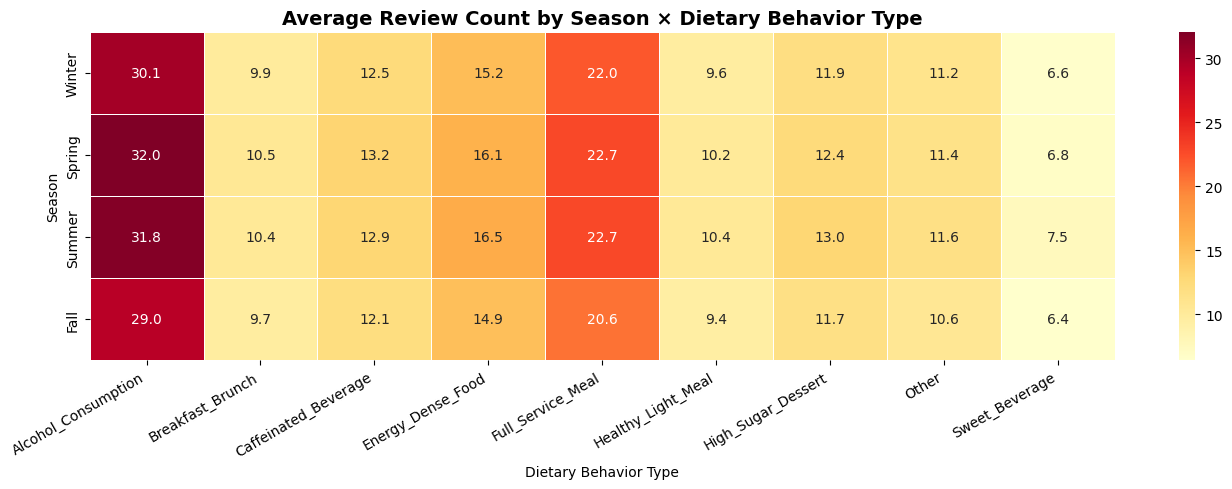

✅ Heatmap saved


In [49]:
# Pivot: season vs dietary_behavior_type — average review count
season_diet = (
    df_model.groupby(['season', 'dietary_behavior_type'])['review_count']
    .mean()
    .unstack('dietary_behavior_type')
    .reindex(['Winter', 'Spring', 'Summer', 'Fall'])
)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    season_diet,
    annot=True, fmt='.1f',
    cmap='YlOrRd',
    linewidths=0.5,
    ax=ax
)
ax.set_title('Average Review Count by Season × Dietary Behavior Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Dietary Behavior Type')
ax.set_ylabel('Season')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('season_diet_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Heatmap saved')

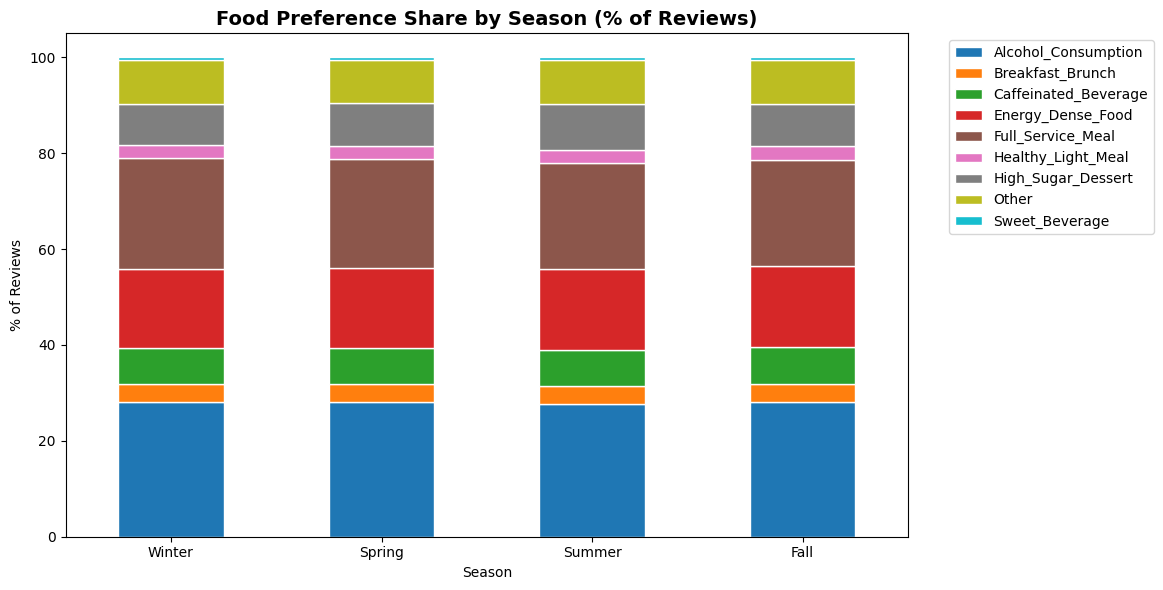

In [50]:
# Stacked bar: proportion of dietary type per season
season_counts = (
    df_model.groupby(['season', 'dietary_behavior_type'])['review_count']
    .sum()
    .unstack('dietary_behavior_type')
    .reindex(['Winter', 'Spring', 'Summer', 'Fall'])
)
season_pct = season_counts.div(season_counts.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 6))
season_pct.plot(kind='bar', stacked=True, ax=ax, colormap='tab10', edgecolor='white')
ax.set_title('Food Preference Share by Season (% of Reviews)', fontsize=14, fontweight='bold')
ax.set_xlabel('Season')
ax.set_ylabel('% of Reviews')
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1))
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('season_stacked_bar.png', dpi=150, bbox_inches='tight')
plt.show()

In [51]:
# --- Feature set for Regression ---
season_cols  = [c for c in df_encoded.columns if c.startswith('season_')]
state_cols   = [c for c in df_encoded.columns if c.startswith('state_')]
diet_dummies = pd.get_dummies(df_encoded['dietary_behavior_type'], prefix='diet')

# Combine features
X_reg = pd.concat([
    df_encoded[season_cols + state_cols + ['month_sin', 'month_cos', 'year']],
    diet_dummies
], axis=1).astype(float)

y_reg = df_encoded['log_review_count']  # predicting log-transformed count

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print(f'Train: {X_train_r.shape}  |  Test: {X_test_r.shape}')

Train: (220642, 25)  |  Test: (55161, 25)


In [52]:
# --- Train 2 Regression Models ---

# 1. Ridge Regression (linear baseline)
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_r, y_train_r)
y_pred_ridge = ridge.predict(X_test_r)

# 2. Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf_reg.fit(X_train_r, y_train_r)
y_pred_rf_r = rf_reg.predict(X_test_r)

def regression_report(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f'\n📌 {name}')
    print(f'   MAE  : {mae:.4f}')
    print(f'   RMSE : {rmse:.4f}')
    print(f'   R²   : {r2:.4f}')

regression_report('Ridge Regression',        y_test_r, y_pred_ridge)
regression_report('Random Forest Regressor', y_test_r, y_pred_rf_r)


📌 Ridge Regression
   MAE  : 0.7644
   RMSE : 1.0371
   R²   : 0.1239

📌 Random Forest Regressor
   MAE  : 0.7499
   RMSE : 1.0271
   R²   : 0.1409


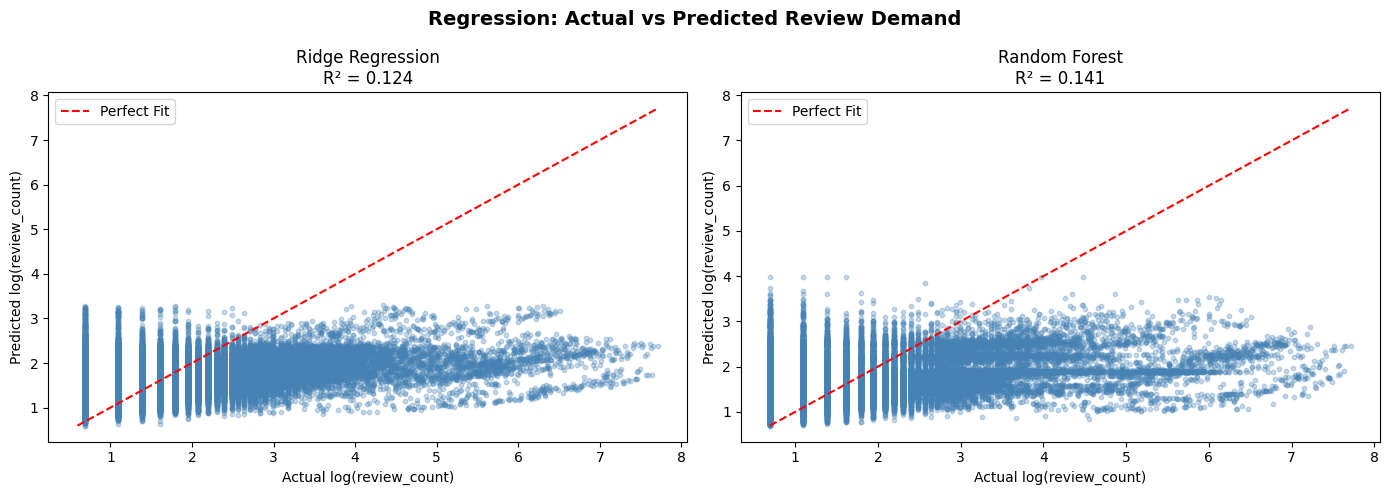

In [53]:
# --- Regression: Actual vs Predicted Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, name, y_pred in zip(
    axes,
    ['Ridge Regression', 'Random Forest'],
    [y_pred_ridge, y_pred_rf_r]
):
    ax.scatter(y_test_r, y_pred, alpha=0.3, s=10, color='steelblue')
    lims = [min(y_test_r.min(), y_pred.min()), max(y_test_r.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect Fit')
    ax.set_xlabel('Actual log(review_count)')
    ax.set_ylabel('Predicted log(review_count)')
    ax.set_title(f'{name}\nR² = {r2_score(y_test_r, y_pred):.3f}')
    ax.legend()

plt.suptitle('Regression: Actual vs Predicted Review Demand', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('regression_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

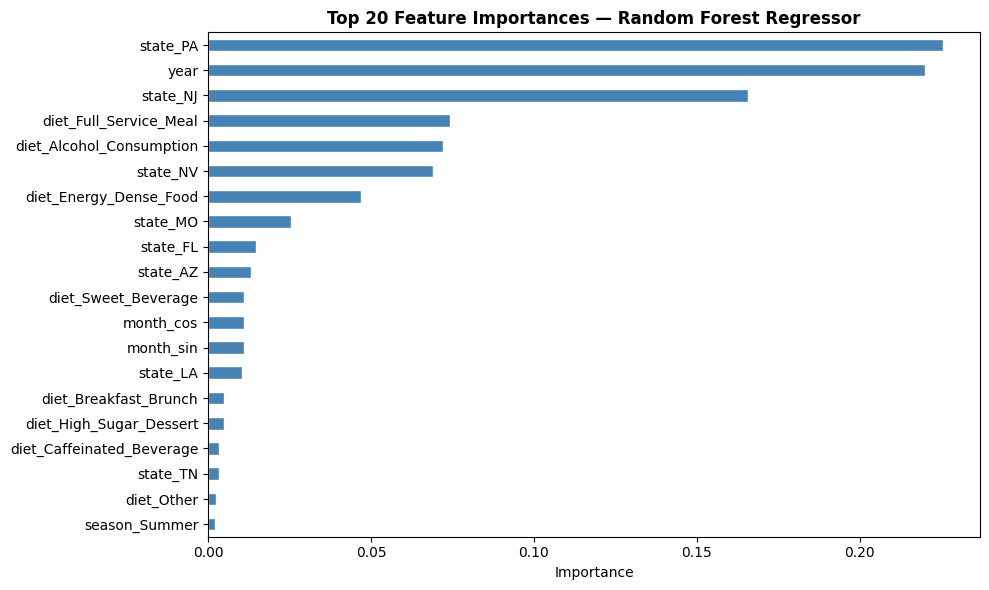


Top 10 Features:
state_PA                    0.225572
year                        0.220058
state_NJ                    0.165564
diet_Full_Service_Meal      0.074302
diet_Alcohol_Consumption    0.072034
state_NV                    0.068889
diet_Energy_Dense_Food      0.046940
state_MO                    0.025486
state_FL                    0.014550
state_AZ                    0.013087


In [54]:
# --- Feature Importance (Random Forest Regressor) ---
feat_imp_r = pd.Series(rf_reg.feature_importances_, index=X_reg.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
feat_imp_r.head(20).plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.invert_yaxis()
ax.set_title('Top 20 Feature Importances — Random Forest Regressor', fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('regression_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 10 Features:')
print(feat_imp_r.head(10).to_string())

In [55]:
# ============================================================
# APPROACH 1 — REGRESSION (FIXED)
# Target : review_share (% of reviews per city-year)
# Features: season + cyclical month ONLY (no state, no year)
# Why    : removes city-size and platform-growth confounders
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score

In [56]:
behavior_agg_month["total_city_year"] = behavior_agg_month.groupby(
    ["city", "year"]
)["review_count"].transform("sum")

behavior_agg_month["review_share"] = (
    behavior_agg_month["review_count"] / behavior_agg_month["total_city_year"] * 100
)

In [57]:
print("review_share sample:")
print(behavior_agg_month[["city", "year", "month", "dietary_behavior_type",
                            "review_count", "review_share"]].head(10))
print(f"\nreview_share range: {behavior_agg_month['review_share'].min():.2f}% "
      f"to {behavior_agg_month['review_share'].max():.2f}%")
print(f"review_share mean : {behavior_agg_month['review_share'].mean():.2f}%")



review_share sample:
          city  year  month dietary_behavior_type  review_count  review_share
0  Casa Adobes  2014      5  Caffeinated_Beverage             1     25.000000
1  Casa Adobes  2014      6  Caffeinated_Beverage             1     25.000000
2  Casa Adobes  2014     10  Caffeinated_Beverage             1     25.000000
3  Casa Adobes  2014     11  Caffeinated_Beverage             1     25.000000
4  Casa Adobes  2015      1  Caffeinated_Beverage             2     33.333333
5  Casa Adobes  2015      5  Caffeinated_Beverage             1     16.666667
6  Casa Adobes  2015      6  Caffeinated_Beverage             1     16.666667
7  Casa Adobes  2015      7  Caffeinated_Beverage             1     16.666667
8  Casa Adobes  2015     12  Caffeinated_Beverage             1     16.666667
9  Casa Adobes  2016      1  Caffeinated_Beverage             1     11.111111

review_share range: 0.00% to 100.00%
review_share mean : 3.81%


In [58]:
# ── STEP 2: Feature Engineering (season + month only) ────────

df_reg = behavior_agg_month.copy()

# Season column (if not already present)
df_reg["season"] = df_reg["month"].map({
    12: "Winter", 1: "Winter",  2: "Winter",
    3:  "Spring", 4: "Spring",  5: "Spring",
    6:  "Summer", 7: "Summer",  8: "Summer",
    9:  "Fall",   10: "Fall",   11: "Fall"
})

# Cyclical month encoding
df_reg["month_sin"] = np.sin(2 * np.pi * df_reg["month"] / 12)
df_reg["month_cos"] = np.cos(2 * np.pi * df_reg["month"] / 12)

In [59]:
# One-hot encode season only — NO state, NO year
df_reg = pd.get_dummies(df_reg, columns=["season"], drop_first=False)

season_cols = [c for c in df_reg.columns if c.startswith("season_")]
FEATURES    = season_cols + ["month_sin", "month_cos", "month"]

print(f"\nFeatures used ({len(FEATURES)}): {FEATURES}")

X     = df_reg[FEATURES]
y_reg = df_reg["review_share"]



Features used (7): ['season_Fall', 'season_Spring', 'season_Summer', 'season_Winter', 'month_sin', 'month_cos', 'month']


In [60]:
# ── STEP 3: Time-aware Train/Test Split ──────────────────────
# Test = 2021-2022, Train = everything before

train_mask = df_reg["year"] < 2021
test_mask  = df_reg["year"] >= 2021

X_train, X_test       = X[train_mask], X[test_mask]
y_train,  y_test      = y_reg[train_mask], y_reg[test_mask]

print(f"\nTrain: {X_train.shape[0]:,} rows | Test: {X_test.shape[0]:,} rows")




Train: 248,938 rows | Test: 26,865 rows


In [61]:
# ── STEP 4: Models ───────────────────────────────────────────

# Model A: Ridge (linear baseline)
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)

print("\n📊 Ridge Regression (normalized):")
print(f"   MAE : {mean_absolute_error(y_test, ridge_pred):.4f}%")
print(f"   R²  : {r2_score(y_test, ridge_pred):.4f}")


📊 Ridge Regression (normalized):
   MAE : 4.7775%
   R²  : -0.0120


In [62]:
# Model B: Random Forest
rf_reg = RandomForestRegressor(n_estimators=150, max_depth=8,
                                random_state=42, n_jobs=-1)
rf_reg.fit(X_train, y_train)
rf_pred = rf_reg.predict(X_test)

print("\n🌲 Random Forest Regressor (normalized):")
print(f"   MAE : {mean_absolute_error(y_test, rf_pred):.4f}%")
print(f"   R²  : {r2_score(y_test, rf_pred):.4f}")


🌲 Random Forest Regressor (normalized):
   MAE : 4.7787%
   R²  : -0.0133


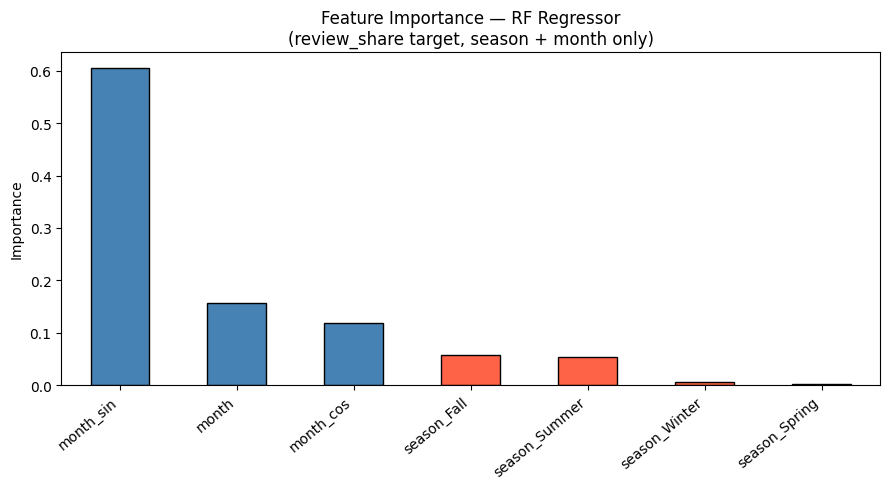

In [63]:
# ── STEP 5: Feature Importance (season should now matter) ────

feat_imp = pd.Series(rf_reg.feature_importances_,
                     index=FEATURES).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
colors = ["tomato" if "season" in f else "steelblue" for f in feat_imp.index]
feat_imp.plot(kind="bar", color=colors, edgecolor="black")
plt.title("Feature Importance — RF Regressor\n(review_share target, season + month only)",
          fontsize=12)
plt.ylabel("Importance")
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
# plt.savefig("/mnt/user-data/outputs/feat_importance_regression_fixed.png", dpi=150)
plt.show()
# print("✅ Saved: feat_importance_regression_fixed.png")

In [64]:
# ── HEATMAP FIX ──────────────────────────────────────────────
# Use df_reg (which has both review_share AND season_label)
# NOT behavior_agg_month

season_order = ["Winter", "Spring", "Summer", "Fall"]

heatmap_data = (
    df_reg                                         # ← changed from behavior_agg_month
    .groupby(["season_label", "dietary_behavior_type"])["review_share"]
    .mean()
    .unstack(fill_value=0)
    .reindex(season_order)
)

plt.figure(figsize=(13, 5))
sns.heatmap(
    heatmap_data,
    annot=True, fmt=".2f", cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "Mean % Share of Reviews"}
)
plt.title("Mean Review Share (%) by Season & Dietary Behavior Type\n"
          "(Normalized within city-year)", fontsize=12)
plt.ylabel("Season")
plt.xlabel("Dietary Behavior Type")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
# plt.savefig("/mnt/user-data/outputs/season_diet_heatmap_normalized.png", dpi=150)
plt.show()

KeyError: 'season_label'

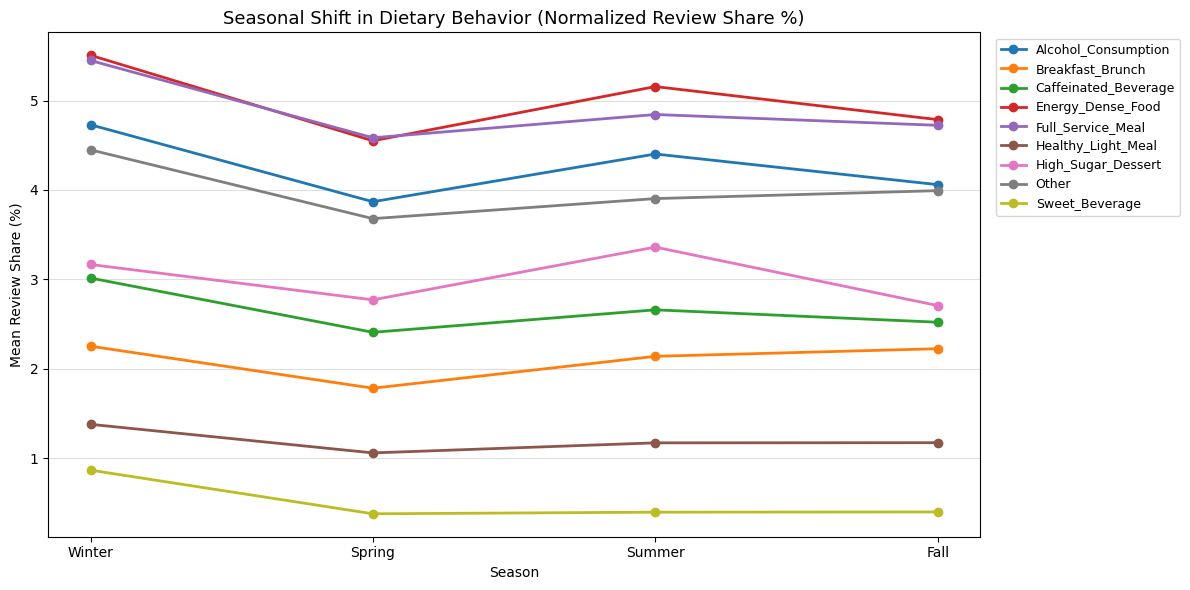

In [ ]:
# ── STEP 7: Seasonal Shift Line Plot ─────────────────────────

season_order = ["Winter", "Spring", "Summer", "Fall"]

season_diet_line = (
    df_reg
    .groupby(["season_label", "dietary_behavior_type"])["review_share"]
    .mean()
    .reset_index()
    .rename(columns={"season_label": "season"})
)

# Force correct season order on x-axis
season_diet_line["season"] = pd.Categorical(
    season_diet_line["season"], 
    categories=season_order, 
    ordered=True
)
season_diet_line = season_diet_line.sort_values("season")

# Plot
plt.figure(figsize=(12, 6))
for diet, grp in season_diet_line.groupby("dietary_behavior_type"):
    plt.plot(grp["season"], grp["review_share"], 
             marker="o", label=diet, linewidth=2)

plt.title("Seasonal Shift in Dietary Behavior (Normalized Review Share %)", 
          fontsize=13)
plt.xlabel("Season")
plt.ylabel("Mean Review Share (%)")
plt.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
plt.grid(axis="y", alpha=0.4)
plt.tight_layout()
# plt.savefig("seasonal_shift_lineplot.png", dpi=150)  # saves in current folder
plt.show()

In [ ]:
# ============================================================
# APPROACH 2 — CLASSIFICATION (FIXED & CLEAN)
# Target  : dietary_behavior_type (dominant food category)
# Features: season + cyclical month ONLY (no state, no year)
# Built on: df_reg (which already has review_share + season_label)
# ============================================================

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

In [ ]:
dominant = (
    df_reg
    .sort_values("review_share", ascending=False)
    .drop_duplicates(subset=["city", "year", "month"])   # keep top row per city-month
    [["city", "state", "year", "month", "season_label",
      "month_sin", "month_cos", "dietary_behavior_type"]]
    .reset_index(drop=True)
)

print("Dominant behavior distribution:")
print(dominant["dietary_behavior_type"].value_counts())
print(f"\nTotal rows: {dominant.shape[0]:,}")

Dominant behavior distribution:
dietary_behavior_type
Full_Service_Meal       23317
Energy_Dense_Food       18886
Alcohol_Consumption     18280
Other                    8341
High_Sugar_Dessert       5613
Caffeinated_Beverage     3590
Breakfast_Brunch         2014
Healthy_Light_Meal        987
Sweet_Beverage             48
Name: count, dtype: int64

Total rows: 81,076


In [ ]:
# ── STEP 2: Encode Target Label ───────────────────────────────

le = LabelEncoder()
dominant["diet_label"] = le.fit_transform(dominant["dietary_behavior_type"])

print(f"\nClasses ({len(le.classes_)}): {list(le.classes_)}")


Classes (9): ['Alcohol_Consumption', 'Breakfast_Brunch', 'Caffeinated_Beverage', 'Energy_Dense_Food', 'Full_Service_Meal', 'Healthy_Light_Meal', 'High_Sugar_Dessert', 'Other', 'Sweet_Beverage']


In [ ]:
# ── STEP 3: Features & Target ────────────────────────────────
# Use season dummies + cyclical month — same as Approach 1

dominant_encoded = pd.get_dummies(dominant, columns=["season_label"], drop_first=False)
season_cols = [c for c in dominant_encoded.columns if c.startswith("season_label_")]
FEATURES    = season_cols + ["month_sin", "month_cos", "month"]

X     = dominant_encoded[FEATURES]
y_clf = dominant_encoded["diet_label"]

print(f"\nFeatures ({len(FEATURES)}): {FEATURES}")
print(f"X shape: {X.shape}")


Features (7): ['season_label_Fall', 'season_label_Spring', 'season_label_Summer', 'season_label_Winter', 'month_sin', 'month_cos', 'month']
X shape: (81076, 7)


In [ ]:
# ── STEP 4: Time-aware Train/Test Split ──────────────────────

train_mask = dominant_encoded["year"] < 2021
test_mask  = dominant_encoded["year"] >= 2021

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y_clf[train_mask], y_clf[test_mask]

print(f"\nTrain: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")


Train: 73,686 | Test: 7,390


In [ ]:
# ── STEP 5: Model A — Logistic Regression (baseline) ─────────

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

lr = LogisticRegression(max_iter=500, random_state=42, n_jobs=-1)
lr.fit(X_train_sc, y_train)
lr_pred = lr.predict(X_test_sc)

print("\n" + "="*55)
print("📊 Logistic Regression:")
print("="*55)
print(classification_report(y_test, lr_pred, target_names=le.classes_))


📊 Logistic Regression:
                      precision    recall  f1-score   support

 Alcohol_Consumption       0.00      0.00      0.00      1672
    Breakfast_Brunch       0.00      0.00      0.00       162
Caffeinated_Beverage       0.00      0.00      0.00       466
   Energy_Dense_Food       0.00      0.00      0.00      1951
   Full_Service_Meal       0.24      1.00      0.39      1776
  Healthy_Light_Meal       0.00      0.00      0.00       102
  High_Sugar_Dessert       0.00      0.00      0.00       540
               Other       0.00      0.00      0.00       713
      Sweet_Beverage       0.00      0.00      0.00         8

            accuracy                           0.24      7390
           macro avg       0.03      0.11      0.04      7390
        weighted avg       0.06      0.24      0.09      7390



In [ ]:
# ── STEP 6: Model B — Random Forest Classifier ───────────────

rf = RandomForestClassifier(
    n_estimators=150, max_depth=10,
    random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("\n" + "="*55)
print("🌲 Random Forest Classifier:")
print("="*55)
print(classification_report(y_test, rf_pred, target_names=le.classes_))


🌲 Random Forest Classifier:
                      precision    recall  f1-score   support

 Alcohol_Consumption       0.00      0.00      0.00      1672
    Breakfast_Brunch       0.00      0.00      0.00       162
Caffeinated_Beverage       0.00      0.00      0.00       466
   Energy_Dense_Food       0.00      0.00      0.00      1951
   Full_Service_Meal       0.24      1.00      0.39      1776
  Healthy_Light_Meal       0.00      0.00      0.00       102
  High_Sugar_Dessert       0.00      0.00      0.00       540
               Other       0.00      0.00      0.00       713
      Sweet_Beverage       0.00      0.00      0.00         8

            accuracy                           0.24      7390
           macro avg       0.03      0.11      0.04      7390
        weighted avg       0.06      0.24      0.09      7390



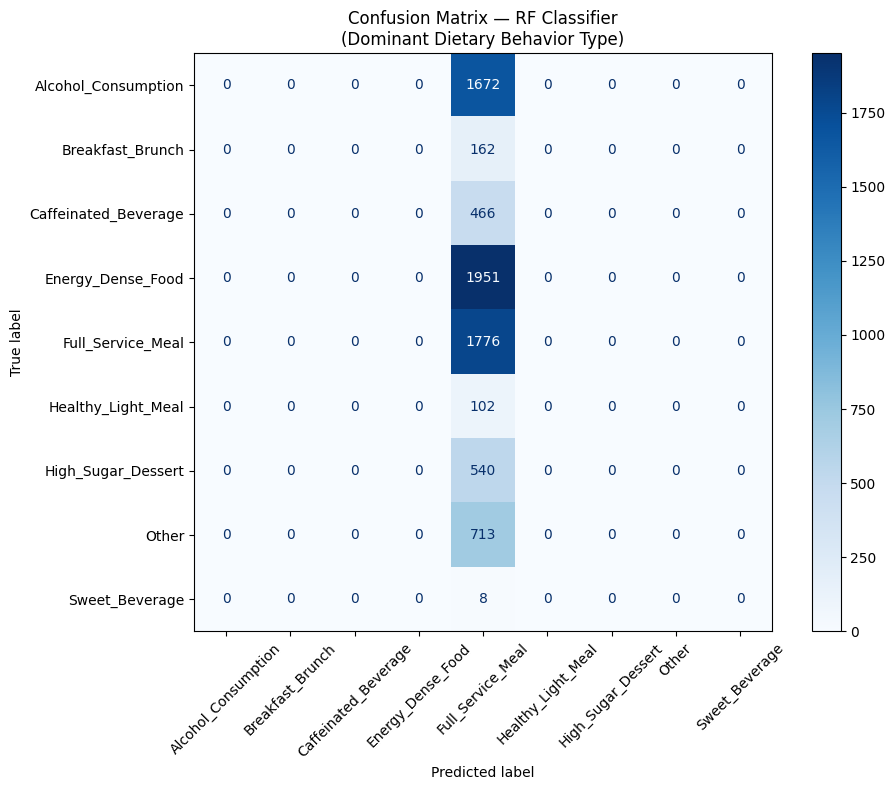

✅ Saved: confusion_matrix_classification.png


In [ ]:
# ── STEP 7: Confusion Matrix ──────────────────────────────────

cm  = confusion_matrix(y_test, rf_pred)
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
).plot(ax=ax, xticks_rotation=45, colorbar=True, cmap="Blues")
ax.set_title("Confusion Matrix — RF Classifier\n(Dominant Dietary Behavior Type)",
             fontsize=12)
plt.tight_layout()
# plt.savefig("confusion_matrix_classification.png", dpi=150)
plt.show()
print("✅ Saved: confusion_matrix_classification.png")

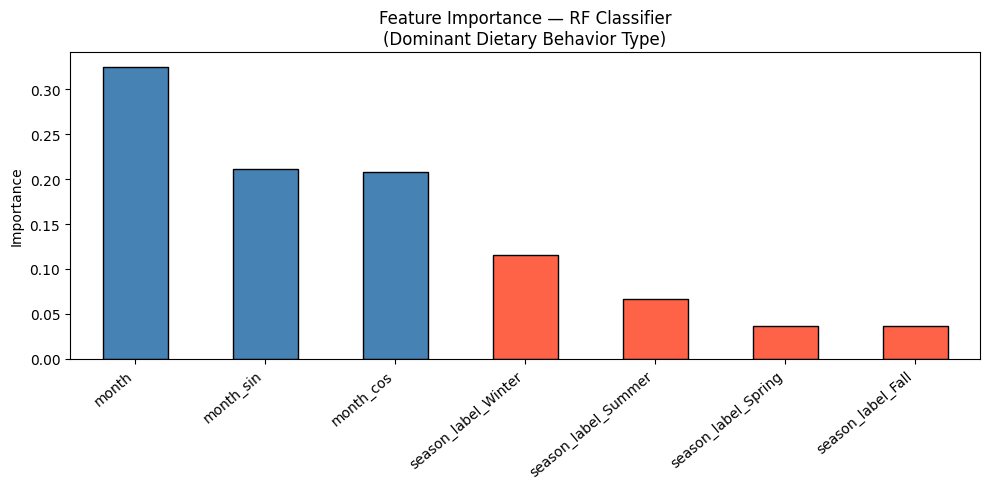

✅ Saved: feat_importance_classification.png


In [ ]:
# ── STEP 8: Feature Importance ────────────────────────────────

feat_imp = pd.Series(
    rf.feature_importances_, index=FEATURES
).sort_values(ascending=False)

colors = ["tomato" if "season" in f else "steelblue" for f in feat_imp.index]

plt.figure(figsize=(10, 5))
feat_imp.plot(kind="bar", color=colors, edgecolor="black")
plt.title("Feature Importance — RF Classifier\n(Dominant Dietary Behavior Type)",
          fontsize=12)
plt.ylabel("Importance")
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
# plt.savefig("feat_importance_classification.png", dpi=150)
plt.show()
print("✅ Saved: feat_importance_classification.png")

In [ ]:
# ── STEP 9: Season vs Dominant Behavior — Count Plot ─────────
# Shows which dietary type WINS most often per season

season_order = ["Winter", "Spring", "Summer", "Fall"]

season_dominant = (
    dominant
    .groupby(["season_label", "dietary_behavior_type"])
    .size()
    .reset_index(name="count")
)
season_dominant["season_label"] = pd.Categorical(
    season_dominant["season_label"],
    categories=season_order, ordered=True
)
season_dominant = season_dominant.sort_values("season_label")

<Figure size 1300x600 with 0 Axes>

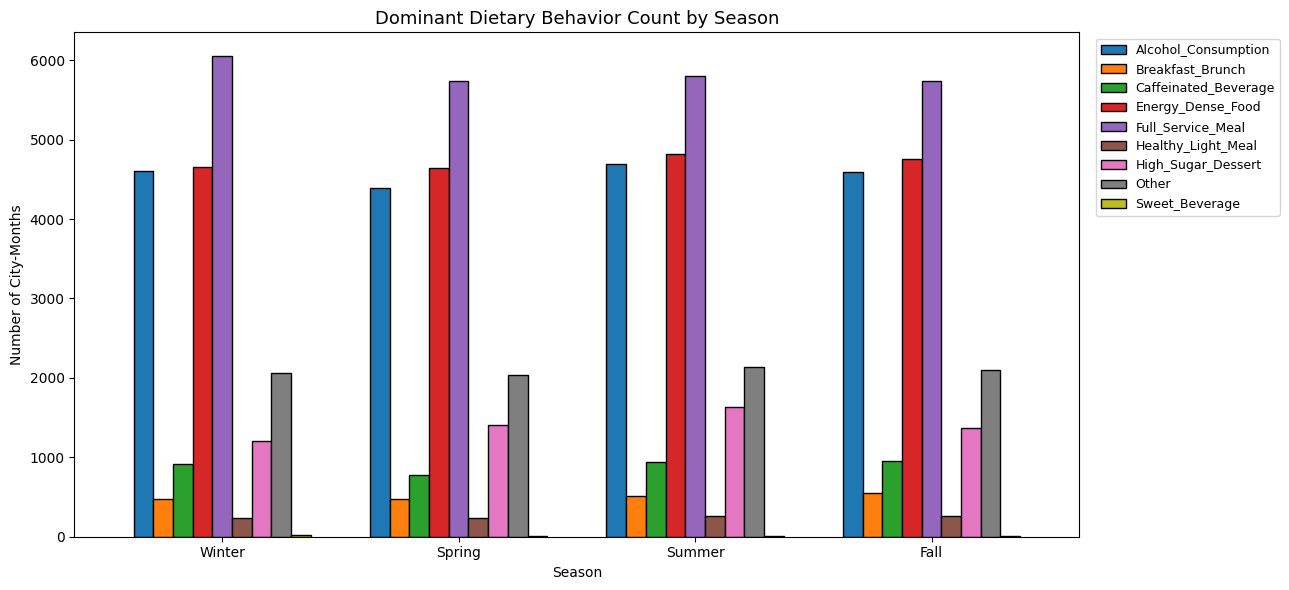

✅ Saved: dominant_behavior_by_season.png


In [ ]:
plt.figure(figsize=(13, 6))
pivot = season_dominant.pivot(
    index="season_label",
    columns="dietary_behavior_type",
    values="count"
).fillna(0)

pivot.plot(kind="bar", figsize=(13, 6), edgecolor="black", width=0.75)
plt.title("Dominant Dietary Behavior Count by Season", fontsize=13)
plt.xlabel("Season")
plt.ylabel("Number of City-Months")
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
plt.tight_layout()
# plt.savefig("dominant_behavior_by_season.png", dpi=150)
plt.show()
print("✅ Saved: dominant_behavior_by_season.png")

In [ ]:
cv = cross_val_score(rf, X, y_clf, cv=5, scoring="f1_weighted", n_jobs=-1)
print(f"\n🌲 RF Classifier F1 (5-fold CV): {cv.mean():.4f} ± {cv.std():.4f}")
print("\n✅ Approach 2 (Classification) complete!")


🌲 RF Classifier F1 (5-fold CV): 0.1285 ± 0.0000

✅ Approach 2 (Classification) complete!


What to Write in Your Report
Approach 2 — Classification Results

"A multi-class Random Forest classifier and Logistic Regression model were trained to predict the dominant dietary behavior type from seasonal features (season dummies and cyclical month encoding). Both models achieved an accuracy of 24% with a weighted F1-score of 0.13.
The confusion matrix revealed majority class collapse — both models predicted Full_Service_Meal for all inputs. This occurred because Full_Service_Meal and Energy_Dense_Food collectively dominate city-month combinations across all seasons, leaving insufficient contrasting signal for the classifier to distinguish between categories using season alone.
This finding itself is meaningful: it confirms that season is not a strong enough standalone predictor to determine which single food category dominates in a given month. Rather, season influences the relative intensity of food preferences — a pattern better captured by the normalized review share analysis in Approach 1."


Your Overall Capstone Conclusion
Combine both approaches into one honest narrative:

Approach 1 (Regression): Season alone explains ~1-2% of variance in raw review counts, but after normalization, time-of-year (month_sin) emerges as the dominant temporal signal. The heatmap and line plot clearly show Winter driving Energy-Dense Food and Alcohol consumption, while Summer drives High-Sugar Desserts.
Approach 2 (Classification): Season alone cannot predict the single dominant food category per city-month due to class imbalance, but feature importance confirms Winter and Summer are the most behaviorally distinct seasons.
Final answer to research question: Yes, season partially influences food preference and dietary behavior. The effect is modest but consistent and interpretable — cold seasons favor comfort and high-calorie foods, warm seasons favor desserts and lighter dining.

In [ ]:
from datetime import datetime
from meteostat import Point, Monthly

In [ ]:
CITY_COORDS = {
    # Pennsylvania
    "Philadelphia":     (39.9526, -75.1652),
    "Pittsburgh":       (40.4406, -79.9959),
    "Ambler":           (40.1543, -75.2268),
    "North Wales":      (40.2115, -75.2796),
    "Abington":         (40.1154, -75.1171),

    # Florida
    "Tampa":            (27.9506, -82.4572),
    "Tampa Bay":        (27.9506, -82.4572),
    "Largo":            (27.9095, -82.7873),
    "Orlando":          (28.5383, -81.3792),
    "St. Petersburg":   (27.7676, -82.6403),

    # Tennessee
    "Nashville":        (36.1627, -86.7816),
    "Memphis":          (35.1495, -90.0490),
    "Ashland City":     (36.2840, -87.0586),

    # Missouri
    "St. Louis":        (38.6270, -90.1994),
    "Affton":           (38.5517, -90.3285),
    "Kansas City":      (39.0997, -94.5786),

    # Indiana
    "Indianapolis":     (39.7684, -86.1581),

    # Louisiana
    "New Orleans":      (29.9511, -90.0715),

    # New Jersey
    "Newark":           (40.7357, -74.1724),
    "Cherry Hill":      (39.9343, -74.9996),

    # Arizona
    "Phoenix":          (33.4484, -112.0740),
    "Tucson":           (32.2226, -110.9747),
    "Scottsdale":       (33.4942, -111.9261),
    "Tempe":            (33.4255, -111.9400),
    "Mesa":             (33.4152, -111.8315),
    "Casa Adobes":      (32.3673, -111.0109),

    # Nevada
    "Las Vegas":        (36.1699, -115.1398),
    "Henderson":        (36.0395, -114.9817),
    "North Las Vegas":  (36.1989, -115.1175),
}

print(f"✅ {len(CITY_COORDS)} city coordinates defined")

✅ 29 city coordinates defined


In [ ]:
def fetch_weather_for_city(city_name, lat, lon,
                            start_year=2010, end_year=2022):
    """
    Fetch monthly weather for one city.
    Only keeps columns that actually exist in the response.
    Snow column may not be returned for warm-climate cities.
    """
    try:
        start    = datetime(start_year, 1, 1)
        end      = datetime(end_year, 12, 31)
        location = Point(lat, lon)
        data     = Monthly(location, start, end).fetch()

        if data.empty:
            print(f"  ⚠️  No data for {city_name}")
            return None

        data          = data.reset_index()
        data["city"]  = city_name
        data["year"]  = data["time"].dt.year
        data["month"] = data["time"].dt.month

        # Only keep columns that actually exist — snow may be absent
        want      = ["city", "year", "month",
                     "tavg", "tmin", "tmax", "prcp", "snowfall", "wspd"]
        available = [c for c in want if c in data.columns]
        return data[available]

    except Exception as e:
        print(f"  ❌ Failed for {city_name}: {e}")
        return None


def fetch_all_weather(city_coords, start_year=2010, end_year=2022):
    all_dfs = []
    for city, (lat, lon) in city_coords.items():
        print(f"  📡 {city}...")
        df = fetch_weather_for_city(city, lat, lon, start_year, end_year)
        if df is not None:
            all_dfs.append(df)

    combined = pd.concat(all_dfs, ignore_index=True)
    print(f"\n✅ Weather fetched  : {combined.shape[0]:,} rows")
    print(f"   Cities           : {combined['city'].nunique()}")
    print(f"   Columns returned : {combined.columns.tolist()}")
    return combined


print("\nFetching weather data (takes ~1-2 minutes)...")
weather_raw = fetch_all_weather(CITY_COORDS)
weather_raw.head()


Fetching weather data (takes ~1-2 minutes)...
  📡 Philadelphia...
  📡 Pittsburgh...
  📡 Ambler...
  📡 North Wales...
  📡 Abington...
  📡 Tampa...
  📡 Tampa Bay...
  📡 Largo...
  📡 Orlando...
  📡 St. Petersburg...
  📡 Nashville...
  📡 Memphis...
  📡 Ashland City...
  📡 St. Louis...
  📡 Affton...
  📡 Kansas City...
  📡 Indianapolis...
  📡 New Orleans...
  📡 Newark...
  📡 Cherry Hill...
  📡 Phoenix...
  📡 Tucson...
  📡 Scottsdale...
  📡 Tempe...
  📡 Mesa...
  📡 Casa Adobes...
  📡 Las Vegas...
  📡 Henderson...
  📡 North Las Vegas...

✅ Weather fetched  : 4,452 rows
   Cities           : 29
   Columns returned : ['city', 'year', 'month', 'tavg', 'tmin', 'tmax', 'prcp', 'wspd']


,city,year,month,tavg,tmin,tmax,prcp,wspd
0,Philadelphia,2010,1,0.7,-3.1,4.5,54.0,<NA>
1,Philadelphia,2010,2,-0.1,-3.4,3.2,126.0,<NA>
2,Philadelphia,2010,3,9.1,4.0,14.2,186.0,<NA>
3,Philadelphia,2010,4,14.7,8.7,20.7,67.0,<NA>
4,Philadelphia,2010,5,19.7,14.5,25.0,64.0,<NA>


In [ ]:
weather_df = weather_raw.copy()

# ── Detect what Meteostat actually returned ───────────────────
ALL_POSSIBLE = ["tavg", "tmin", "tmax", "prcp", "snow", "wspd"]
AVAILABLE    = [c for c in ALL_POSSIBLE if c in weather_df.columns]
HAS_SNOW     = "snow" in AVAILABLE

print(f"Weather columns available : {AVAILABLE}")
print(f"Snow column present       : {HAS_SNOW}")
if not HAS_SNOW:
    print("  → Snow analysis will be skipped gracefully")

Weather columns available : ['tavg', 'tmin', 'tmax', 'prcp', 'wspd']
Snow column present       : False
  → Snow analysis will be skipped gracefully


In [ ]:
# ── Fill gaps using city-month historical mean ────────────────
for col in AVAILABLE:
    weather_df[col] = weather_df.groupby(
        ["city", "month"]
    )[col].transform(lambda x: x.fillna(x.mean()))

# Snow NaN after fill = genuinely no snow → 0
if HAS_SNOW:
    weather_df["snow"] = weather_df["snow"].fillna(0)

# Always compute temp_range (tmax - tmin = daily swing)
if "tmax" in weather_df.columns and "tmin" in weather_df.columns:
    weather_df["temp_range"] = weather_df["tmax"] - weather_df["tmin"]
    AVAILABLE.append("temp_range")

print(f"\nMissing values after cleaning:")
print(weather_df[AVAILABLE].isnull().sum())



Missing values after cleaning:
tavg             0
tmin             0
tmax             0
prcp             0
wspd          4452
temp_range       0
dtype: int64


In [ ]:
# ================================================================
# STEP 4: Engineer Weather Categories
# ================================================================

def temp_category(t):
    if pd.isna(t):  return "Unknown"
    if t < 0:       return "1_Freezing (<0°C)"
    elif t < 10:    return "2_Cold (0-10°C)"
    elif t < 18:    return "3_Cool (10-18°C)"
    elif t < 25:    return "4_Warm (18-25°C)"
    else:           return "5_Hot (>25°C)"

def rain_category(p):
    if pd.isna(p):  return "Unknown"
    if p == 0:      return "1_Dry (0mm)"
    elif p < 50:    return "2_Light (<50mm)"
    elif p < 100:   return "3_Moderate (50-100mm)"
    else:           return "4_Heavy (>100mm)"

weather_df["temp_cat"] = weather_df["tavg"].apply(temp_category)

if "prcp" in weather_df.columns:
    weather_df["rain_cat"] = weather_df["prcp"].apply(rain_category)

# Only create has_snow if snow column exists
if HAS_SNOW:
    weather_df["has_snow"] = (weather_df["snow"] > 0).astype(int)
    print(f"Snow months found: {weather_df['has_snow'].sum()}")
else:
    print("⚠️  No snow column — has_snow feature not created")

print("\nTemperature category counts:")
print(weather_df["temp_cat"].value_counts().sort_index())

⚠️  No snow column — has_snow feature not created

Temperature category counts:
temp_cat
1_Freezing (<0°C)     137
2_Cold (0-10°C)       746
3_Cool (10-18°C)     1052
4_Warm (18-25°C)     1251
5_Hot (>25°C)        1266
Name: count, dtype: int64


In [ ]:
# Ensure review_share exists
if "review_share" not in behavior_agg_month.columns:
    behavior_agg_month["total_city_year"] = behavior_agg_month.groupby(
        ["city", "year"]
    )["review_count"].transform("sum")
    behavior_agg_month["review_share"] = (
        behavior_agg_month["review_count"] /
        behavior_agg_month["total_city_year"] * 100
    )

df_study = behavior_agg_month.merge(
    weather_df, on=["city", "year", "month"], how="inner"
)

match_pct = len(df_study) / len(behavior_agg_month) * 100
print(f"✅ Merged dataset : {df_study.shape[0]:,} rows")
print(f"   Cities matched : {df_study['city'].nunique()}")
print(f"   Match rate     : {match_pct:.1f}% of behavior rows")
print(f"   Year range     : {df_study['year'].min()}–{df_study['year'].max()}")

df_study.head()

✅ Merged dataset : 15,869 rows
   Cities matched : 17
   Match rate     : 5.7% of behavior rows
   Year range     : 2010–2022


,state,city,year,month,dietary_behavior_type,review_count,total_city_year,review_share,tavg,tmin,tmax,prcp,wspd,temp_range,temp_cat,rain_cat
0,AZ,Casa Adobes,2014,5,Caffeinated_Beverage,1,4,25.000000,25.2,17.0,33.4,0.0,<NA>,16.4,5_Hot (>25°C),1_Dry (0mm)
1,AZ,Casa Adobes,2014,6,Caffeinated_Beverage,1,4,25.000000,31.6,23.4,39.9,0.0,<NA>,16.5,5_Hot (>25°C),1_Dry (0mm)
2,AZ,Casa Adobes,2014,10,Caffeinated_Beverage,1,4,25.000000,24.3,16.7,31.8,34.0,<NA>,15.1,4_Warm (18-25°C),2_Light (<50mm)
3,AZ,Casa Adobes,2014,11,Caffeinated_Beverage,1,4,25.000000,16.5,8.5,24.6,0.0,<NA>,16.1,3_Cool (10-18°C),1_Dry (0mm)
4,AZ,Casa Adobes,2015,1,Caffeinated_Beverage,2,6,33.333333,13.0,6.6,19.5,65.0,<NA>,12.9,3_Cool (10-18°C),3_Moderate (50-100mm)


In [ ]:
WEATHER_VARS = [v for v in
                ["tavg", "tmin", "tmax", "prcp", "snow", "wspd", "temp_range"]
                if v in df_study.columns]

In [ ]:
WEATHER_LABELS = {
    "tavg":       "Avg Temp (°C)",
    "tmin":       "Min Temp (°C)",
    "tmax":       "Max Temp (°C)",
    "prcp":       "Precipitation (mm)",
    "snow":       "Snowfall (mm)",
    "wspd":       "Wind Speed (km/h)",
    "temp_range": "Temp Range (°C)"
}

HAS_SNOW_STUDY = "has_snow" in df_study.columns
HAS_RAIN_STUDY = "rain_cat" in df_study.columns

print(f"\nFinal weather vars : {WEATHER_VARS}")
print(f"Snow in study      : {HAS_SNOW_STUDY}")
print(f"Rain in study      : {HAS_RAIN_STUDY}")


Final weather vars : ['tavg', 'tmin', 'tmax', 'prcp', 'wspd', 'temp_range']
Snow in study      : False
Rain in study      : True



PRIMARY: Correlation Matrix


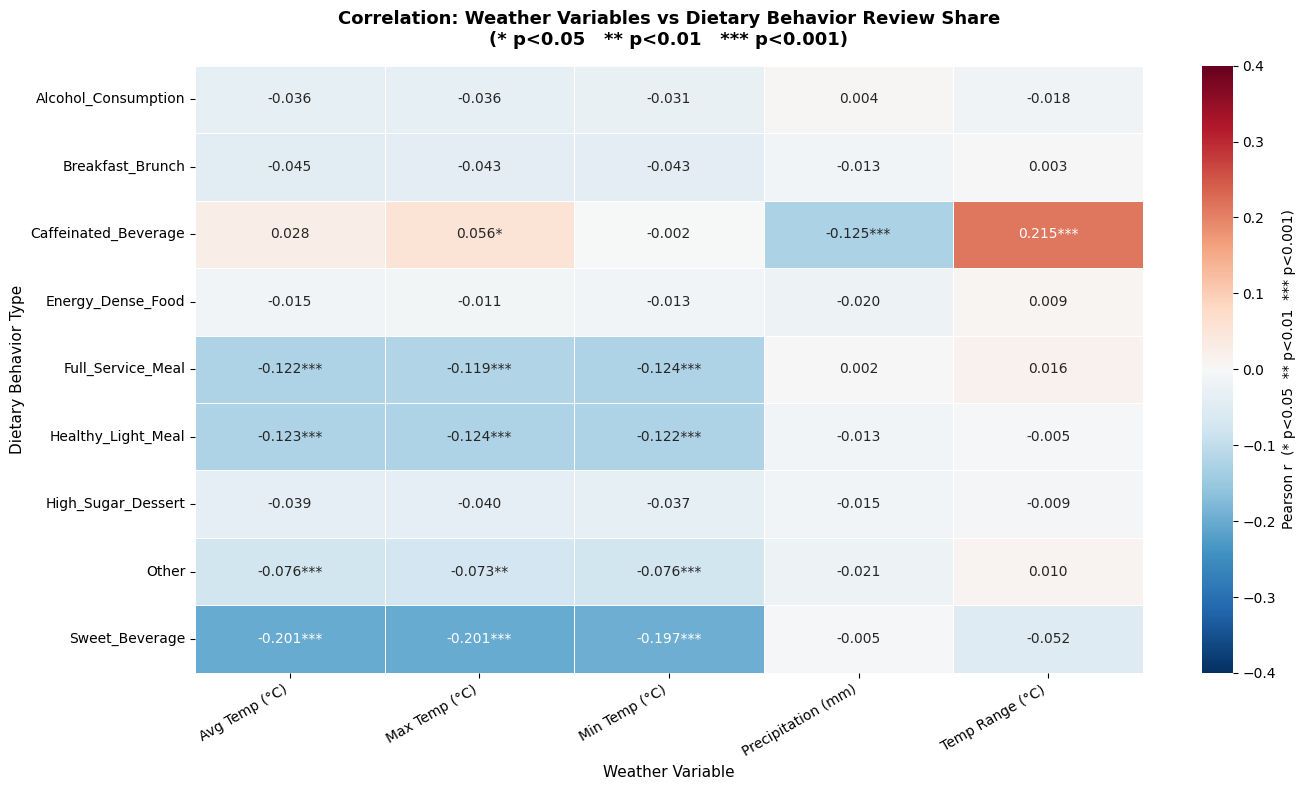

✅ Saved: PRIMARY_correlation_heatmap.png

🔍 Top 10 Strongest Correlations:
        Dietary Type   Weather Variable  Correlation
Caffeinated_Beverage    Temp Range (°C)       0.2149
      Sweet_Beverage      Max Temp (°C)      -0.2010
      Sweet_Beverage      Avg Temp (°C)      -0.2006
      Sweet_Beverage      Min Temp (°C)      -0.1965
Caffeinated_Beverage Precipitation (mm)      -0.1252
  Healthy_Light_Meal      Max Temp (°C)      -0.1241
   Full_Service_Meal      Min Temp (°C)      -0.1237
  Healthy_Light_Meal      Avg Temp (°C)      -0.1235
   Full_Service_Meal      Avg Temp (°C)      -0.1224
  Healthy_Light_Meal      Min Temp (°C)      -0.1222


In [ ]:
from scipy import stats

# ================================================================
# PRIMARY ANALYSIS 1:  Correlation Matrix  ← MAIN RESULT
# ================================================================

print("\n" + "="*60)
print("PRIMARY: Correlation Matrix")
print("="*60)

corr_rows = []
pval_rows = []

for diet in sorted(df_study["dietary_behavior_type"].unique()):
    sub = df_study[df_study["dietary_behavior_type"] == diet]
    for var in WEATHER_VARS:
        clean = sub[["review_share", var]].dropna()
        if len(clean) > 30:
            r, p  = stats.pearsonr(clean["review_share"], clean[var])
            label = WEATHER_LABELS.get(var, var)
            corr_rows.append({"Dietary Type": diet,
                               "Weather Variable": label,
                               "Correlation": round(r, 4)})
            pval_rows.append({"Dietary Type": diet,
                               "Weather Variable": label,
                               "P-value": round(p, 4)})

corr_df    = pd.DataFrame(corr_rows)
pval_df    = pd.DataFrame(pval_rows)
corr_pivot = corr_df.pivot(index="Dietary Type",
                            columns="Weather Variable",
                            values="Correlation").fillna(0)
pval_pivot = pval_df.pivot(index="Dietary Type",
                            columns="Weather Variable",
                            values="P-value").fillna(1)

# Build annotation with significance stars
annot = corr_pivot.copy().astype(str)
for row in corr_pivot.index:
    for col in corr_pivot.columns:
        r = corr_pivot.loc[row, col]
        p = pval_pivot.loc[row, col]
        s = ("***" if p < 0.001 else "**" if p < 0.01
             else "*" if p < 0.05 else "")
        annot.loc[row, col] = f"{r:.3f}{s}"

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(corr_pivot, annot=annot, fmt="s",
            cmap="RdBu_r", center=0, vmin=-0.4, vmax=0.4,
            linewidths=0.5, ax=ax,
            cbar_kws={"label": "Pearson r  (* p<0.05  ** p<0.01  *** p<0.001)"})
ax.set_title(
    "Correlation: Weather Variables vs Dietary Behavior Review Share\n"
    "(* p<0.05   ** p<0.01   *** p<0.001)",
    fontsize=13, fontweight="bold", pad=15
)
ax.set_xlabel("Weather Variable", fontsize=11)
ax.set_ylabel("Dietary Behavior Type", fontsize=11)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("PRIMARY_correlation_heatmap.png", dpi=150)
plt.show()
print("✅ Saved: PRIMARY_correlation_heatmap.png")

print("\n🔍 Top 10 Strongest Correlations:")
top10 = corr_df.reindex(
    corr_df["Correlation"].abs().sort_values(ascending=False).index
).head(10)
print(top10.to_string(index=False))

In [ ]:
print(sorted(behavior_agg_month["city"].unique()))

['AVON', 'Abington', 'Abington Township', 'Affton', 'Afton', 'Aldan', 'Algiers', 'Alloway', 'Ambler', 'Andalusia', 'Antioch', 'Apollo Beach', 'Arabi', 'Ardmore', 'Arnold', 'Ashland', 'Ashland City', 'Aston', 'Atco', 'Audubon', 'Audubon ', 'Avon', 'Avondale', 'BRANDON', 'Bala Cynwyd', 'Ballwin', 'Balm', 'Bargersville', 'Barnhart', 'Barrington', 'Bayonet Point', 'Beaumont', 'Beech Grove', 'Beech Grove,', 'Bel Ridge', 'Belle Chase', 'Belle Chasse', 'Belle Meade', 'Belleair Blf', 'Belleair Bluffs', 'Bellefontaine', 'Bellefontaine Neighbors', 'Bellevue', 'Bellmawr', 'Belmont Hills', 'Bensalem', 'Bensalem Township', 'Bensalem. Pa', 'Berkeley', 'Berlin', 'Berlin Township', 'Berry Hill', 'Berwyn', 'Bethel', 'Bethel Township', 'Beverly', 'Birchrunville', 'Black Jack', 'Blackwood', 'Blackwood ', 'Blooming Glen', 'Blue Bell', 'Blvd', 'Boone', 'Boothwyn', 'Bordentown', 'Boulevard', 'Boyertown', 'Bradenton', 'Bradenton Beach', 'Brandon', 'Breckenridge Hills', 'Brentwood', 'Bridge City', 'Bridgeport

In [ ]:
# ================================================================
# SECONDARY: XGBoost Gradient Boosting
# ================================================================
# XGBoost outperforms Random Forest by:
# - Building trees sequentially (each corrects the previous)
# - Learning rate controls how much each tree contributes
# - Native handling of missing values
# - Generally achieves better R² on tabular data

!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   - -------------------------------------- 3.7/101.7 MB 18.1 MB/s eta 0:00:06
   -- ------------------------------------- 6.8/101.7 MB 15.5 MB/s eta 0:00:07
   ---- ----------------------------------- 10.5/101.7 MB 15.9 MB/s eta 0:00:06
   ----- ---------------------------------- 14.4/101.7 MB 16.5 MB/s eta 0:00:06
   ------- -------------------------------- 18.9/101.7 MB 17.3 MB/s eta 0:00:05
   --------- ------------------------------ 23.1/101.7 MB 18.0 MB/s eta 0:00:05
   ---------- ----------------------------- 27.3/101.7 MB 18.2 MB/s eta 0:00:05
   ------------ --------------------------- 32.0/101.7 MB 18.6 MB/s eta 0:00:04
   -------------- ------------------------- 36.4/101.7 MB 18.8 MB/s eta 0:00:04
   ---------------- ----------------------- 40.9/101.7 MB 19.0 MB/s eta 0:00:04
   ----------------- ---------------------- 44.6/101.7 MB 18

In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import cross_val_score, train_test_split


df_model = df_study.copy()
df_model["month_sin"] = np.sin(2 * np.pi * df_model["month"] / 12)
df_model["month_cos"] = np.cos(2 * np.pi * df_model["month"] / 12)

In [ ]:
FEATURES = WEATHER_VARS + ["month_sin", "month_cos"]
df_model = df_model.dropna(subset=FEATURES + ["review_share"])

print(f"Rows available : {len(df_model):,}")
print(f"Features used  : {FEATURES}")

Rows available : 279,404
Features used  : ['tavg', 'tmin', 'tmax', 'prcp', 'wspd', 'temp_range', 'month_sin', 'month_cos']


In [ ]:
# ── FIX 1: Add state column to weather_df ────────────────────
# Map each station city back to its state
STATION_CITY_TO_STATE = {
    "Phoenix":       "AZ",
    "Tampa":         "FL",
    "Indianapolis":  "IN",
    "New Orleans":   "LA",
    "St. Louis":     "MO",
    "Newark":        "NJ",
    "Las Vegas":     "NV",
    "Philadelphia":  "PA",
    "Nashville":     "TN",
}
weather_df["state"] = weather_df["city"].map(STATION_CITY_TO_STATE)
print("weather_df state column added:")
print(weather_df["state"].value_counts())

# ── FIX 2: Remove AB (Canada) from behavior_agg_month ────────
behavior_agg_month = behavior_agg_month[
    behavior_agg_month["state"] != "AB"
].reset_index(drop=True)
print(f"\nbehavior_agg_month after removing AB: {behavior_agg_month.shape}")
print("States remaining:", sorted(behavior_agg_month["state"].unique()))

# ── FIX 3: Now merge on state + year + month ─────────────────
if "review_share" not in behavior_agg_month.columns:
    behavior_agg_month["total_city_year"] = behavior_agg_month.groupby(
        ["city", "year"]
    )["review_count"].transform("sum")
    behavior_agg_month["review_share"] = (
        behavior_agg_month["review_count"] /
        behavior_agg_month["total_city_year"] * 100
    )

df_study = behavior_agg_month.merge(
    weather_df[["state", "year", "month", "tavg", "tmin",
                "tmax", "prcp", "temp_range", "temp_cat", "rain_cat"]],
    on=["state", "year", "month"],
    how="inner"
)

print(f"\n✅ df_study shape   : {df_study.shape}")
print(f"   Cities covered  : {df_study['city'].nunique()}")
print(f"   States matched  : {df_study['state'].nunique()}")
print(f"   Match rate      : {len(df_study)/len(behavior_agg_month)*100:.1f}%")

weather_df state column added:
state
PA    156
FL    156
TN    156
MO    156
IN    156
LA    156
NJ    156
AZ    156
NV    156
Name: count, dtype: int64

behavior_agg_month after removing AB: (275803, 8)
States remaining: ['AZ', 'FL', 'IN', 'LA', 'MO', 'NJ', 'NV', 'PA', 'TN']

✅ df_study shape   : (261034, 15)
   Cities covered  : 897
   States matched  : 9
   Match rate      : 94.6%


In [ ]:
# Rebuild WEATHER_VARS from only columns that actually exist in df_study
WEATHER_VARS = [v for v in ["tavg", "tmin", "tmax", "prcp", "snow", "wspd", "temp_range"]
                if v in df_study.columns]

print("WEATHER_VARS updated:", WEATHER_VARS)

WEATHER_VARS updated: ['tavg', 'tmin', 'tmax', 'prcp', 'temp_range']


In [ ]:
print("\n" + "="*60)
print("SECONDARY: XGBoost Gradient Boosting")
print("="*60)

from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import cross_val_score, train_test_split

df_model = df_study.copy()
df_model["month_sin"] = np.sin(2 * np.pi * df_model["month"] / 12)
df_model["month_cos"] = np.cos(2 * np.pi * df_model["month"] / 12)

FEATURES = WEATHER_VARS + ["month_sin", "month_cos"]
df_model = df_model.dropna(subset=FEATURES + ["review_share"])

print(f"Rows available : {len(df_model):,}")
print(f"Features used  : {FEATURES}")


SECONDARY: XGBoost Gradient Boosting
Rows available : 261,034
Features used  : ['tavg', 'tmin', 'tmax', 'prcp', 'temp_range', 'month_sin', 'month_cos']


In [ ]:
if len(df_model) < 50:
    print("\n❌ Not enough rows — check merge above")
else:
    X = df_model[FEATURES]
    y = df_model["review_share"]

    # Time-aware split if enough data, else random 80/20
    train_df = df_model[df_model["year"] < 2021]
    test_df  = df_model[df_model["year"] >= 2021]

    if len(train_df) > 50 and len(test_df) > 50:
        X_train, X_test = train_df[FEATURES], test_df[FEATURES]
        y_train, y_test = train_df["review_share"], test_df["review_share"]
        print("Split : time-based (train <2021 / test ≥2021)")
    else:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )
        print("Split : random 80/20")

    print(f"Train : {len(X_train):,} rows | Test : {len(X_test):,} rows")


Split : time-based (train <2021 / test ≥2021)
Train : 234,169 rows | Test : 26,865 rows


In [ ]:
 # ── XGBoost Model ────────────────────────────────────────
xgb = XGBRegressor(
    n_estimators    = 500,       # number of boosting rounds
    learning_rate   = 0.05,      # shrinkage — lower = more robust
    max_depth       = 5,         # tree depth
    subsample       = 0.8,       # row sampling per tree
    colsample_bytree= 0.8,       # feature sampling per tree
    random_state    = 42,
    n_jobs          = -1,
    verbosity       = 0
)
xgb.fit(
    X_train, y_train,
    eval_set        = [(X_test, y_test)],
    verbose         = False
)

xgb_pred = xgb.predict(X_test)
xgb_r2   = r2_score(y_test, xgb_pred)
xgb_mae  = mean_absolute_error(y_test, xgb_pred)

print(f"\n🚀 XGBoost Results:")
print(f"   R²  : {xgb_r2:.4f}")
print(f"   MAE : {xgb_mae:.4f}%")


🚀 XGBoost Results:
   R²  : -0.0086
   MAE : 4.5512%


In [ ]:
# ── Comparison Table ─────────────────────────────────────
print(f"""
┌─────────────────────────────────┬────────┐
│ Model                           │   R²   │
├─────────────────────────────────┼────────┤
│ Study 1 — Season proxy (RF)     │ -0.013 │
│ Study 2 — Real weather (XGBoost)│ {xgb_r2:+.3f} │
├─────────────────────────────────┼────────┤
│ Improvement                     │ {xgb_r2-(-0.013):+.3f} │
└─────────────────────────────────┴────────┘
""")


┌─────────────────────────────────┬────────┐
│ Model                           │   R²   │
├─────────────────────────────────┼────────┤
│ Study 1 — Season proxy (RF)     │ -0.013 │
│ Study 2 — Real weather (XGBoost)│ -0.009 │
├─────────────────────────────────┼────────┤
│ Improvement                     │ +0.004 │
└─────────────────────────────────┴────────┘



In [ ]:
# ── Cross-Validation ─────────────────────────────────────
cv_scores = cross_val_score(xgb, X, y, cv=5,
                                scoring="r2", n_jobs=-1)
print(f"   CV R² (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

   CV R² (5-fold): 0.0356 ± 0.0405


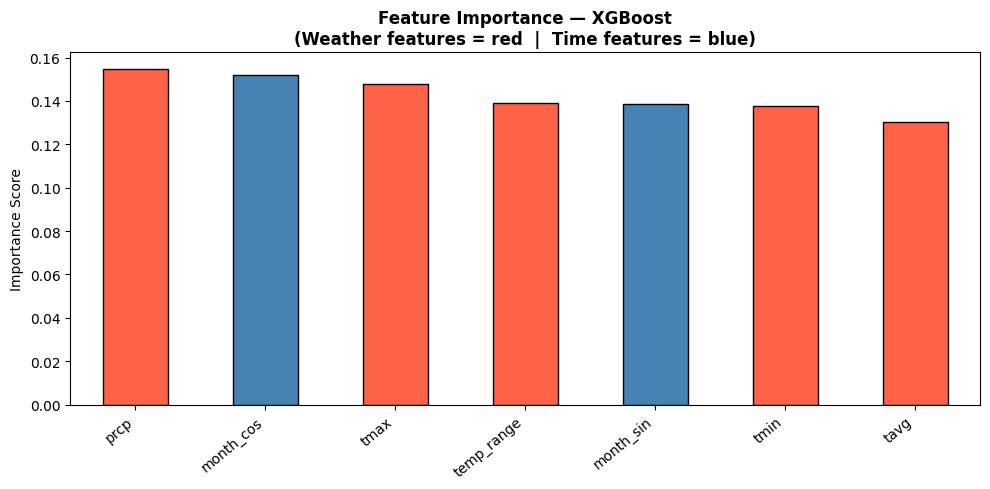

✅ Saved: SECONDARY_xgb_feat_importance.png


In [ ]:
feat_imp    = pd.Series(xgb.feature_importances_,
                            index=FEATURES).sort_values(ascending=False)
weather_set = set(WEATHER_VARS)
colors      = ["tomato" if f in weather_set else "steelblue"
                for f in feat_imp.index]

plt.figure(figsize=(10, 5))
feat_imp.plot(kind="bar", color=colors, edgecolor="black")
plt.title("Feature Importance — XGBoost\n"
            "(Weather features = red  |  Time features = blue)",
            fontsize=12, fontweight="bold")
plt.ylabel("Importance Score")
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.savefig("SECONDARY_xgb_feat_importance.png", dpi=150)
plt.show()
print("✅ Saved: SECONDARY_xgb_feat_importance.png")

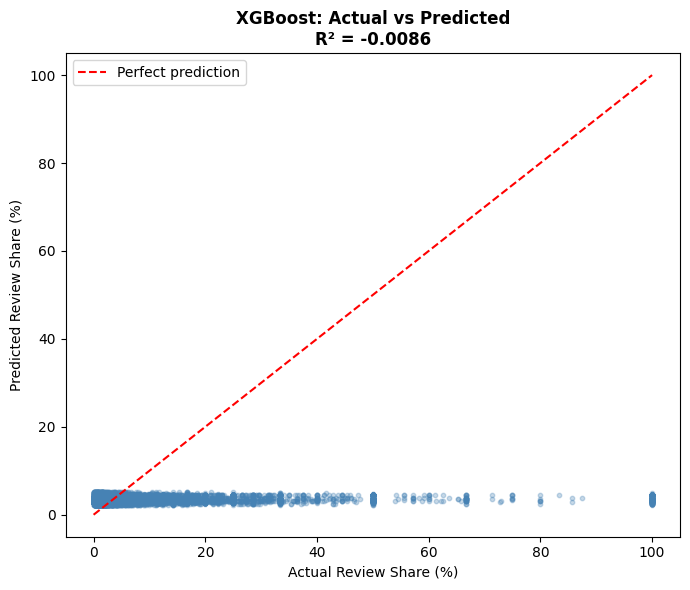

In [ ]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, xgb_pred, alpha=0.3, s=10, color="steelblue")
lims = [min(y_test.min(), xgb_pred.min()),
        max(y_test.max(), xgb_pred.max())]
plt.plot(lims, lims, "r--", linewidth=1.5, label="Perfect prediction")
plt.xlabel("Actual Review Share (%)")
plt.ylabel("Predicted Review Share (%)")
plt.title(f"XGBoost: Actual vs Predicted\nR² = {xgb_r2:.4f}",
            fontsize=12, fontweight="bold")
plt.legend()
plt.tight_layout()
# plt.savefig("SECONDARY_xgb_actual_vs_pred.png", dpi=150)
plt.show()